# Sidra: Hotspot Detection on Reclaimed Land
## Pilot site: Diyar Al Muharraq, Bahrain

**Team Sidra** · Arab Youth Space Hackathon 2026 · Theme: Urban Expansion, Land Use Change & Heat Risk

**The problem:** Bahrain is building new districts on land reclaimed from the sea. In summer this land becomes far hotter than the sea it replaced, and within a development some areas run hotter than others. Developers and planners have no site-specific evidence of where heat concentrates on their reclaimed land, or what is causing it.

**What this notebook does:** Using free satellite data, it:
1. identifies which land was reclaimed from the sea, and when;
2. measures how much hotter that ground became once it turned from sea into land;
3. detects the parts of the development that are persistently the hottest in summer;
4. examines what surface lies under those hotspots;
5. turns the result into zone-by-zone feedback a developer can act on.

**Data sources:** Landsat Collection 2 Level-2 surface temperature and reflectance (USGS), Sentinel-2 Level-2A reflectance (ESA Copernicus) and the Impact Observatory / Esri 10 m annual land cover map, all accessed through Microsoft Planetary Computer. Every value is computed from these sources when the notebook runs. Numbers quoted in the text are from the run of 7 October 2026.

## 1. Why this matters

**Who it is for:** Coastal developers, municipal authorities and environmental planners who decide the physical layout of reclaimed districts: how dense the built-up area is, where open space goes, how much water is kept between islands.

**What they use today:** Post-construction assessments, sparse weather stations, or general design guidelines. None of these tell them, for their own site, where heat concentrates and what is driving it.

**The physical problem:** Reclamation replaces shallow sea with land. In summer daytime, land surfaces get much hotter than water. The reason is not that water reflects more sunlight (it actually reflects very little, roughly 5 to 10 percent). Water stays cooler because it stores a large amount of heat without warming much, mixes that heat downward, and loses heat by evaporation. Dry fill sand, asphalt and concrete have none of these advantages, so they heat up quickly under the same sun.

**Why satellites:** Landsat has measured surface temperature over Bahrain since the 1980s. That lets us look at the *same location* before (when it was sea) and after (when it became land), and track how each part of a development behaves across many summers, which no ground sensor network in Bahrain can do. The method only needs a study box and a site location, so the same notebook can assess any reclamation project.

## 2. The questions this notebook answers

| # | Question | Method |
|---|---|---|
| Q1 | Which land in the study area was reclaimed from the sea, and when? | Yearly water maps from Landsat (1998 to 2025) |
| Q2 | How much hotter did the reclaimed ground become, compared with when it was sea? | Summer surface temperature at the same pixels, before vs after |
| Q3 | Inside Diyar Al Muharraq, which areas are *persistently* the hottest? | Multi-summer temperature anomalies, a spatial hotspot test (Getis-Ord Gi\*), and how often each spot ranks in the hottest 10% |
| Q4 | What surface sits under those hotspots: bare fill, buildings or vegetation? | Sentinel-2 vegetation and water mapping plus a 10 m land cover map |
| Q5 | What practical feedback follows for a developer? | Rule-based guidance per hotspot zone, from the measured surface mix |

**Results saved:** a GeoTIFF of all map layers, a table with one row per 30 m pixel, the hotspot zone outlines with their guidance, an interactive map, and a metrics file listing every satellite scene used.

## 3. Method at a glance and the key decisions

| Decision | What we chose | Why | Main alternative and why not |
|---|---|---|---|
| Data platform | Microsoft Planetary Computer, through its STAC catalogue | Free, no account needed, searchable by location and date, streams only the small window we need | Google Earth Engine needs per-user sign-up, harder for a reviewer to rerun |
| Temperature source | Landsat Collection 2 Level-2 Surface Temperature (Landsat 8 and 9 for recent years, Landsat 5 and 7 for the "before" years) | The only free archive with thermal measurements reaching back before Diyar existed | MODIS has daily data but 1 km pixels, which would turn all of Diyar into a handful of pixels |
| Season | June to September only | Heat risk is a summer problem. Winter scenes show weak contrasts that would understate it | Using all seasons mixes very different conditions |
| Number of images | Every usable summer scene over five recent summers | A single day can be distorted by wind, haze or one unusual afternoon. A hotspot that keeps reappearing is real | A single image cannot separate a real hotspot from a one-day accident |
| Comparing different days | Each day's temperatures are expressed relative to that same day (relative to open sea, or relative to Diyar's own median) | Removes day-to-day weather swings so scenes can be combined | Averaging raw temperatures lets hot days dominate |
| Hotspot test | Getis-Ord Gi\* on 90 m cells, corrected for multiple testing, plus persistence | Gi\* finds *clusters* of high values that are unlikely to be chance, not isolated noisy pixels. Persistence checks the result holds across summers | A simple "top 10% of pixels" threshold flags noise and edges equally |
| Grid | 30 m, UTM zone 39N (EPSG:32639), all layers on one identical grid; hotspots on 90 m cells (3 by 3 pixels) | 30 m is Landsat's delivery grid. Sentinel-2 10 m data is averaged into each 30 m cell exactly (3 by 3 pixels). 90 m matches what the thermal sensor can actually resolve | Upsampling temperature to 10 m copies one temperature into nine pixels and creates false precision |
| Shoreline | Land within a measured distance of water is left out of the hotspot ranking | Near the shore, the sea cools the land and the sensor footprint mixes in sea temperature. Without this, the "coolest" places in Diyar would just be its waterfronts | Ranking all land makes the hotspot map a map of distance from the water |

**Resolution limit:** Landsat's thermal sensor sees about 100 m (Landsat 8/9) or 120 m (Landsat 5) on the ground. It is delivered on a 30 m grid, but features smaller than roughly 100 m cannot be resolved in temperature. That is why hotspot detection works on 90 m cells, and why our hotspots are block-scale, not building-scale.

## 4. Setup

### 4.1 Import the libraries

**What this does:** Loads the tools into memory. Nothing visible happens if it works.

In [ ]:
import json, math, platform, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy import ndimage, stats
from pyproj import Transformer

import pystac_client
import planetary_computer
import odc.stac
from odc.geo.geobox import GeoBox
import rasterio
from rasterio import features
from rasterio.enums import Resampling
import rioxarray  # noqa: F401  (adds the .rio accessor used for the land cover map)
import geopandas as gpd
from shapely.geometry import shape
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)  # all-NaN slices over open water are expected
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11})
print("Libraries loaded. Python", platform.python_version())

Libraries loaded. Python 3.13.16


### 4.2 Analysis settings

**What this does:** Puts every choice that affects the results in one place, so a reviewer can see and change them without hunting through the code. The comment next to each setting says why it has that value.

**The study box:** Diyar Al Muharraq is listed at roughly 26.31° N, 50.63° E and measures about 3.9 km by 3.4 km. The box below is about 12 km by 9.5 km around it, so that it also contains open sea (our temperature reference) and the older land of Muharraq to the south (a comparison group). We do not draw Diyar's boundary by hand: Section 6 finds it from the satellite record as the land that used to be sea, near that centre point.

**Optional boundary file:** `DIYAR_POLYGON_FILE` accepts an official site boundary in GeoJSON format. When it is set, that boundary replaces the automatic selection. In this run it is empty, so the boundary is derived from the satellite record.

In [ ]:
# ---- Study area -------------------------------------------------------------
STUDY_BBOX = (50.575, 26.270, 50.695, 26.355)   # (min lon, min lat, max lon, max lat)
DIYAR_CENTRE = (50.63, 26.31)                    # (lon, lat), published location of Diyar Al Muharraq
DIYAR_RADIUS_M = 3000        # reclaimed pieces whose centre lies within this distance are treated as Diyar
DIYAR_SEPARATION_PX = 3      # cuts land links narrower than ~200 m (bridges, causeways) to separate developments
DIYAR_POLYGON_FILE = None    # optional: path to an official site boundary (GeoJSON)
CRS = "EPSG:32639"           # UTM zone 39N: metric coordinates, correct zone for Bahrain (48-54° E)
PIXEL_M = 30                 # Landsat grid size in metres

# ---- Reclamation history (Q1) ----------------------------------------------
HISTORY_YEARS = list(range(1998, 2026))  # yearly water maps
BASELINE_WATER_YEARS = (1998, 2002)      # "before": prior to Diyar's reclamation (checked in Section 6)
RECENT_WATER_YEARS = (2023, 2025)        # "now"
HISTORY_MAX_CLOUD = 30                   # % cloud allowed for a scene to be considered
HISTORY_SCENES_PER_YEAR = 8              # clearest scenes used per year (median removes leftovers)
WATER_MNDWI_THRESHOLD = 0.0              # standard split: water > 0, land <= 0
MIN_RECLAIMED_PATCH_PX = 5               # ignore reclaimed specks smaller than ~0.45 ha (noise)
CONVERSION_MIN_LAND_SHARE = 0.8          # land in >= 80% of all later years counts as "converted"

# ---- Summer surface temperature (Q2, Q3) -----------------------------------
SUMMER = ("06-01", "09-30")              # June to September
LST_RECENT_YEARS = list(range(2021, 2026))
LST_BASELINE_CANDIDATE_YEARS = list(range(1995, 2009))  # trimmed automatically to years before reclamation
LST_MAX_CLOUD = 20
MIN_CLEAR_FRACTION = 0.6                 # a scene must see at least 60% of Diyar clearly to be used
SEA_REF_MIN_DIST_M = 300                 # open-sea reference pixels must be this far from any land

# ---- Surface composition (Q4) ----------------------------------------------
S2_YEAR = 2025                           # Sentinel-2 summer used for vegetation and water mapping
S2_MAX_CLOUD = 10
S2_MAX_SCENES = 12
VEG_NDVI_THRESHOLD = 0.25                # irrigated grass, palms and shrubs in Bahrain typically exceed this

# ---- Hotspot detection (Q3) ------------------------------------------------
SHORE_BUFFER_M = "auto"      # land this close to water is not ranked; "auto" = measured from the data (Section 9.1)
SHORE_BUFFER_LIMITS_M = (60, 300)
CELL_M = 90                  # hotspot cell: 3 x 3 Landsat pixels, close to the ~100 m true thermal footprint
MIN_CORE_SHARE = 5 / 9       # a cell is ranked if at least 5 of its 9 pixels are inland Diyar land
GI_RADIUS_M = 135            # Gi* neighbourhood: a cell plus its 8 touching cells
FDR_Q = 0.05                 # accepted share of false alarms among flagged cells (Benjamini-Hochberg)
HOT_PERCENTILE = 90          # "hot" in a scene = in the top 10% of Diyar cells that day
PERSISTENT_MIN_SHARE = 0.5   # persistent = hot in at least half of the clear summer scenes
MIN_ZONE_CELLS = 2           # a hotspot zone must cover at least 2 cells (about 1.6 ha)

# ---- Run settings -------------------------------------------------------------
N_THREADS = 8
import os

start_directory = Path.cwd()
# Find the project root when Jupyter starts in notebooks/.
project_root = next((p for p in [start_directory, *start_directory.parents]
                     if (p / "requirements.txt").is_file()
                     and (p / "notebooks").is_dir()), start_directory)
output_root = Path(os.environ.get("SIDRA_ROOT", project_root)).resolve()
OUT = output_root / "outputs/hotspots"
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "cache").mkdir(parents=True, exist_ok=True)
print("Outputs will be written to", OUT.resolve())

Outputs will be written to /content/outputs/hotspots


### 4.3 Build the shared analysis grid

**What this does:** Creates one 30 m grid (and a matching 10 m grid for Sentinel-2) covering the study box. Every dataset is loaded directly onto these grids.

**Why it matters:** Comparing pixels across years and sensors only works if pixel (row 100, column 200) is the same piece of ground in every layer. The 10 m grid is built so that exactly 3 by 3 of its pixels fall inside each 30 m pixel; the check at the end of the cell confirms this.

In [ ]:
to_utm = Transformer.from_crs("EPSG:4326", CRS, always_xy=True)
to_ll = Transformer.from_crs(CRS, "EPSG:4326", always_xy=True)

corners = [to_utm.transform(lon, lat) for lon in STUDY_BBOX[0::2] for lat in STUDY_BBOX[1::2]]
cx, cy = zip(*corners)
minx, maxx = math.floor(min(cx) / PIXEL_M) * PIXEL_M, math.ceil(max(cx) / PIXEL_M) * PIXEL_M
miny, maxy = math.floor(min(cy) / PIXEL_M) * PIXEL_M, math.ceil(max(cy) / PIXEL_M) * PIXEL_M

GBOX30 = GeoBox.from_bbox((minx, miny, maxx, maxy), crs=CRS, resolution=PIXEL_M)
GBOX10 = GeoBox.from_bbox((minx, miny, maxx, maxy), crs=CRS, resolution=10)
NY, NX = GBOX30.shape.y, GBOX30.shape.x
assert (GBOX10.shape.y, GBOX10.shape.x) == (3 * NY, 3 * NX), "10 m grid does not nest in the 30 m grid"

T30 = GBOX30.affine
xs = T30.c + (np.arange(NX) + 0.5) * PIXEL_M
ys = T30.f - (np.arange(NY) + 0.5) * PIXEL_M
XX, YY = np.meshgrid(xs, ys)
LON, LAT = to_ll.transform(XX, YY)
EXTENT_KM = [minx / 1000, maxx / 1000, miny / 1000, maxy / 1000]
PX_AREA_KM2 = PIXEL_M ** 2 / 1e6

print(f"30 m grid: {NY} rows x {NX} columns = {NY * NX:,} pixels "
      f"({(maxx - minx) / 1000:.1f} km x {(maxy - miny) / 1000:.1f} km)")
print("10 m grid nests exactly in the 30 m grid: OK")

30 m grid: 315 rows x 401 columns = 126,315 pixels (12.0 km x 9.4 km)
10 m grid nests exactly in the 30 m grid: OK


### 4.4 Small helper functions for maps

**What this does:** Defines two short functions used for every map in the notebook: one draws a layer with a colour bar and an optional outline (we outline Diyar), the other saves the figure into `outputs/hotspots/figures` so it can go into the submission and the web app.

In [ ]:
def show(ax, arr, title, cmap="viridis", vmin=None, vmax=None, label="", outline=None, norm=None, cbar=True):
    im = ax.imshow(arr, extent=EXTENT_KM, origin="upper", cmap=cmap, vmin=vmin, vmax=vmax,
                   norm=norm, interpolation="nearest")
    if outline is not None and outline.any():
        ax.contour(outline.astype(float), levels=[0.5], colors="black", linewidths=0.7,
                   extent=EXTENT_KM, origin="upper")
    ax.set_title(title)
    ax.set_xlabel("Easting (km, UTM 39N)")
    ax.set_ylabel("Northing (km)")
    if cbar:
        plt.colorbar(im, ax=ax, shrink=0.75, label=label)
    return im

def save(fig, name):
    fig.savefig(OUT / "figures" / f"{name}.png", dpi=150, bbox_inches="tight")

## 5. Connecting to the data

### 5.1 Open the Planetary Computer catalogue

**What this does:** Connects to Microsoft Planetary Computer's STAC catalogue. STAC (SpatioTemporal Asset Catalog) is a standard way of listing satellite images so they can be searched by place, date and properties such as cloud cover, without downloading anything first.

**Access:** Searching is open. Reading the image files needs a short-lived access token, which `planetary_computer.sign` adds automatically each time a file is read. No account or API key is needed.

In [ ]:
catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
print("Connected to:", catalog.title)

Connected to: Microsoft Planetary Computer STAC API


### 5.2 Search and loading functions

**What this does:** Defines the functions every later step uses to find and load images:

- `search_items` finds scenes over the study box within a date range, with optional cloud and satellite filters, and returns them in date order.
- `load` reads the chosen bands of those scenes onto our grid. Scenes from the same day (neighbouring strips) are merged into one image.
- `landsat_clear` builds a mask of usable pixels from Landsat's quality band (`qa_pixel`). Each pixel stores flags as bits; we reject pixels flagged as fill (bit 0), dilated cloud (bit 1), cirrus (bit 2), cloud (bit 3) or cloud shadow (bit 4).
- `to_reflectance` and `to_celsius` convert stored integers to physical units using the scale factors published by USGS for Collection 2 Level-2: reflectance = DN × 0.0000275 − 0.2, and temperature in kelvin = DN × 0.00341802 + 149.0. A stored value of 0 means "no data".

**Why a separate thermal band name:** Landsat 8 and 9 store surface temperature as `lwir11`; Landsat 5 and 7 store it as `lwir`. `thermal_band` picks the right one per scene so old and new satellites can be combined.

In [ ]:
def item_date(it):
    d = it.datetime or pd.Timestamp(it.properties.get("start_datetime")).to_pydatetime()
    return pd.Timestamp(d).tz_localize(None) if pd.Timestamp(d).tzinfo else pd.Timestamp(d)

def search_items(collection, start, end, max_cloud=None, platforms=None):
    query = {}
    if max_cloud is not None:
        query["eo:cloud_cover"] = {"lt": max_cloud}
    if platforms:
        query["platform"] = {"in": list(platforms)}
    search = catalog.search(collections=[collection], bbox=STUDY_BBOX,
                            datetime=f"{start}/{end}", query=query or None)
    return sorted(search.items(), key=item_date)

def describe(items):
    return pd.DataFrame([{
        "date": item_date(it).date().isoformat(),
        "satellite": it.properties.get("platform", ""),
        "cloud_%": round(float(it.properties.get("eo:cloud_cover", np.nan)), 1),
        "scene_id": it.id,
    } for it in items])

def load(items, bands, geobox, resampling="nearest"):
    return odc.stac.load(items, bands=bands, geobox=geobox, groupby="solar_day",
                         resampling=resampling, patch_url=planetary_computer.sign,
                         fail_on_error=False, pool=N_THREADS, progress=tqdm)

QA_BAD_BITS = (0, 1, 2, 3, 4)   # fill, dilated cloud, cirrus, cloud, cloud shadow

def landsat_clear(qa):
    qa = qa.astype("uint16")
    bad = xr.zeros_like(qa, dtype=bool)
    for bit in QA_BAD_BITS:
        bad = bad | np.bitwise_and(np.right_shift(qa, bit), 1).astype(bool)
    return ~bad

def to_reflectance(dn):
    return xr.where(dn > 0, dn.astype("float32") * 2.75e-05 - 0.2, np.nan).clip(min=1e-4)

def to_celsius(dn):
    return xr.where(dn > 0, dn.astype("float32") * 0.00341802 + 149.0 - 273.15, np.nan)

def thermal_band(item):
    for key in ("lwir11", "lwir"):
        if key in item.assets:
            return key
    raise KeyError(f"No surface temperature band in {item.id}")

def require(items, what):
    if len(items) == 0:
        raise RuntimeError(f"No scenes found for {what}. Check the internet connection and settings; "
                           "this notebook does not substitute simulated data.")
    return items

## 6. Q1: Where is the reclaimed land, and when was it created?

### 6.1 One water map per year, 1998 to 2025

**What this does:** For every year, it takes up to the 8 clearest Landsat scenes, computes the water index MNDWI for each, and keeps the per-pixel median for the year. A pixel is water that year if its median MNDWI is above 0.

**The water index:** MNDWI (Modified Normalised Difference Water Index) = (Green − SWIR1) / (Green + SWIR1). Water reflects some green light but absorbs almost all shortwave infrared, so it scores high. Sand, concrete and soil reflect shortwave infrared strongly, so they score low. MNDWI is preferred over the older NDWI near cities because built surfaces are less likely to be mistaken for water.

**Why the yearly median:** Single scenes can contain leftover cloud, haze, waves or unusual tides. The median of several scenes keeps the typical state of each pixel that year.

**Satellites used:** Landsat 5 (until 2011), Landsat 7, Landsat 8 (from 2013) and Landsat 9 (from 2021). After May 2003 Landsat 7 has a known scan-line fault that leaves diagonal gaps, so we give it lower priority than other satellites in the same year; the median across scenes fills most gaps.

**Run time:** This is the slowest step (roughly 5 to 15 minutes). Results are cached in `outputs/hotspots/cache`, so re-running is quick.

In [ ]:
HISTORY_PLATFORMS = ("landsat-5", "landsat-7", "landsat-8", "landsat-9")

def annual_water(year):
    cache = OUT / "cache" / f"mndwi_{year}.npz"
    if cache.exists():
        d = np.load(cache, allow_pickle=True)
        return d["mndwi"], d["n_clear"], list(d["scenes"])
    items = search_items("landsat-c2-l2", f"{year}-01-01", f"{year}-12-31",
                         max_cloud=HISTORY_MAX_CLOUD, platforms=HISTORY_PLATFORMS)
    if not items:
        return None
    # prefer satellites without the Landsat 7 scan-line fault, then the clearest scenes
    items = sorted(items, key=lambda it: (year > 2003 and it.properties["platform"] == "landsat-7",
                                          it.properties.get("eo:cloud_cover", 100)))
    items = items[:HISTORY_SCENES_PER_YEAR]
    ds = load(items, ["green", "swir16", "qa_pixel"], GBOX30)
    clear = landsat_clear(ds["qa_pixel"])
    green = to_reflectance(ds["green"]).where(clear)
    swir = to_reflectance(ds["swir16"]).where(clear)
    mndwi_t = (green - swir) / (green + swir)
    mndwi = mndwi_t.median("time", skipna=True).values.astype("float32")
    n_clear = np.isfinite(mndwi_t.values).sum(axis=0).astype("int16")
    scenes = [f"{it.id}" for it in items]
    np.savez_compressed(cache, mndwi=mndwi, n_clear=n_clear, scenes=np.array(scenes, dtype=object))
    return mndwi, n_clear, scenes

mndwi_by_year, history_log = {}, []
for year in tqdm(HISTORY_YEARS, desc="Yearly water maps"):
    res = annual_water(year)
    if res is None:
        history_log.append({"year": year, "scenes": 0, "median_clear_obs": 0})
        continue
    mndwi, n_clear, scenes = res
    mndwi_by_year[year] = mndwi
    history_log.append({"year": year, "scenes": len(scenes),
                        "median_clear_obs": int(np.median(n_clear))})

history_log = pd.DataFrame(history_log)
display(history_log.set_index("year").T)
years_ok = sorted(mndwi_by_year)
if len(years_ok) < 10:
    raise RuntimeError("Too few years with usable Landsat data to reconstruct the reclamation history.")
water_by_year = np.stack([np.where(np.isfinite(mndwi_by_year[y]),
                                   (mndwi_by_year[y] > WATER_MNDWI_THRESHOLD).astype("float32"), np.nan)
                          for y in years_ok])
print(f"Usable years: {len(years_ok)} of {len(HISTORY_YEARS)}")

Yearly water maps:   0%|          | 0/28 [00:00<?, ?it/s]

year,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
scenes,8,8,8,8,8,4,7,8,6,8,...,8,8,8,8,8,8,8,8,8,8
median_clear_obs,8,8,8,8,8,4,6,6,5,7,...,8,8,8,8,8,8,8,8,8,8


Usable years: 28 of 28


**What the output shows:** In the table, `scenes` is the number of images used for each year and `median_clear_obs` is how many cloud-free looks a typical pixel got. All 28 years from 1998 to 2025 had usable Landsat data. Most years used 8 scenes with 8 clear looks per pixel. Only 2003, 2004 and 2006 had fewer scenes (4, 7 and 6), because of cloud and the Landsat 7 scan-line fault, and they still give a clear look at a typical pixel 4 to 6 times, enough for a stable yearly median.

### 6.2 Classify every pixel: sea, original land, reclaimed land

**What this does:** Compares the "before" years (1998 to 2002) with the "now" years (2023 to 2025):

| Class | Before | Now | Meaning |
|---|---|---|---|
| Stable sea | water | water | open water throughout |
| Original land | land | land | land that already existed (including older reclamation from before 1998) |
| **Reclaimed land** | water | land | land created from the sea since about 2000 |
| Land to water | land | water | dredged canals, marinas or eroded shore |

A pixel takes the majority state over each period. Reclaimed specks smaller than 5 pixels are removed as noise.

**Why this definition:** It is the only way to separate genuinely reclaimed land from older land. Treating all land in the box as reclaimed would mix old Muharraq neighbourhoods into the result.

In [ ]:
def period_mean(y0, y1):
    idx = [i for i, y in enumerate(years_ok) if y0 <= y <= y1]
    if not idx:
        raise RuntimeError(f"No usable water maps between {y0} and {y1}.")
    return np.nanmean(water_by_year[idx], axis=0), [years_ok[i] for i in idx]

water_before, yrs_before = period_mean(*BASELINE_WATER_YEARS)
water_now, yrs_now = period_mean(*RECENT_WATER_YEARS)

SEA, LAND, RECLAIMED, LOST = 0, 1, 2, 3
CLASS_NAMES = {SEA: "Stable sea", LAND: "Original land", RECLAIMED: "Reclaimed land", LOST: "Land to water"}
known = np.isfinite(water_before) & np.isfinite(water_now)
wb, wn = water_before >= 0.5, water_now >= 0.5
land_class = np.full((NY, NX), np.nan)
land_class[known & wb & wn] = SEA
land_class[known & ~wb & ~wn] = LAND
land_class[known & wb & ~wn] = RECLAIMED
land_class[known & ~wb & wn] = LOST

# remove tiny reclaimed specks (relabel them by their current state)
lab, n = ndimage.label(land_class == RECLAIMED, structure=np.ones((3, 3)))
sizes = ndimage.sum(np.ones_like(lab), lab, index=np.arange(1, n + 1))
tiny = np.isin(lab, np.where(sizes < MIN_RECLAIMED_PATCH_PX)[0] + 1)
land_class[tiny] = LAND

print(f"'Before' years used: {yrs_before}   'Now' years used: {yrs_now}")
summary = pd.Series({CLASS_NAMES[c]: round(np.sum(land_class == c) * PX_AREA_KM2, 2) for c in CLASS_NAMES},
                    name="area_km2")
display(summary.to_frame())

'Before' years used: [1998, 1999, 2000, 2001, 2002]   'Now' years used: [2023, 2024, 2025]


,area_km2
Stable sea,80.33
Original land,8.07
Reclaimed land,25.28
Land to water,0.00


**What the output shows:** The study box covers about 114 km²: 80.3 km² of sea that stayed sea, 8.1 km² of original land (the northern tip of Muharraq Island), and **25.3 km² of land reclaimed from the sea since about 2000**. No land turned back into water. In this part of Bahrain, reclaimed land now covers three times as much area as the original land.

### 6.3 Pick out Diyar Al Muharraq and check it against the published size

**What this does:** Reclaimed land in the box is split into separate pieces, and the pieces near Diyar's published location are taken as Diyar. Other reclaimed land in the box (the reclaimed strip along Muharraq's north coast and Amwaj Islands) is kept as "other reclaimed land", a comparison group.

**The difficulty, and how it is handled:** Neighbouring developments are joined to each other by bridges, causeways and narrow strips of fill, so a simple "connected land" rule treats them all as one piece. Here, that rule produces a single 24 km² piece containing Diyar, the north-coast strip and Amwaj Islands, more than twice Diyar's published size. To separate them, we first erase land links narrower than about 200 m (a standard image operation called morphological opening), select the pieces whose centre lies within 3 km of Diyar's published centre, and then grow those pieces back to their full original outline. If `DIYAR_POLYGON_FILE` is set, an official boundary is used instead.

**Validation:** Diyar Al Muharraq's published project description gives 7 reclaimed islands with 10 km² of reclaimed land, within a 12 km² development (Diyar Al Muharraq press release, 13 April 2021). Our area is measured independently from the satellite record, so comparing the two is a real check of the method. A large difference would point to the wrong pieces being selected, or to development that is still ongoing (the North Islands were still under construction in 2024 to 2025).

In [ ]:
reclaimed = land_class == RECLAIMED
if DIYAR_POLYGON_FILE:
    poly = gpd.read_file(DIYAR_POLYGON_FILE).to_crs(CRS)
    inside = features.rasterize(((g, 1) for g in poly.geometry), out_shape=(NY, NX), transform=T30) == 1
    diyar = reclaimed & inside
    selection_note = f"official boundary from {DIYAR_POLYGON_FILE}"
else:
    cx_utm, cy_utm = to_utm.transform(*DIYAR_CENTRE)
    eight = np.ones((3, 3))
    separated = ndimage.binary_opening(reclaimed, structure=eight, iterations=DIYAR_SEPARATION_PX)
    lab, n = ndimage.label(separated, structure=eight)
    centres = ndimage.center_of_mass(separated, lab, index=np.arange(1, n + 1))
    pieces = []
    for i, (r, c) in enumerate(centres, start=1):
        d = math.hypot(xs[0] + c * PIXEL_M - cx_utm, ys[0] - r * PIXEL_M - cy_utm)
        pieces.append({"piece": i, "area_km2": round(np.sum(lab == i) * PX_AREA_KM2, 2),
                       "distance_to_centre_km": round(d / 1000, 2), "selected_as_diyar": d <= DIYAR_RADIUS_M})
    pieces = pd.DataFrame(pieces).sort_values("distance_to_centre_km")
    display(pieces.set_index("piece"))
    diyar = np.isin(lab, pieces.loc[pieces["selected_as_diyar"], "piece"].values)
    for _ in range(DIYAR_SEPARATION_PX + 1):      # grow back to the full outline, staying on reclaimed land
        diyar = ndimage.binary_dilation(diyar, structure=eight) & reclaimed
    selection_note = (f"{int(pieces['selected_as_diyar'].sum())} reclaimed pieces within "
                      f"{DIYAR_RADIUS_M / 1000:.0f} km of the published centre, after cutting links under ~200 m")

other_reclaimed = reclaimed & ~diyar
diyar_area = diyar.sum() * PX_AREA_KM2
if diyar.sum() == 0:
    raise RuntimeError("No reclaimed land found near Diyar's centre. Check STUDY_BBOX and the water maps.")
print(f"Diyar selection: {selection_note}")
print(f"Diyar reclaimed area measured from satellite: {diyar_area:.2f} km²  (published figure: about 10 km²)")
print(f"Difference from published figure: {100 * (diyar_area - 10) / 10:+.0f}%")
print(f"Other reclaimed land in the study box: {other_reclaimed.sum() * PX_AREA_KM2:.2f} km²")

,area_km2,distance_to_centre_km,selected_as_diyar
piece,,,
5,6.68,0.37,True
1,3.43,2.08,True
3,0.07,2.45,True
4,0.08,2.59,True
2,0.62,2.97,True
6,0.12,3.51,False
7,5.64,3.84,False
11,2.74,3.95,False
8,1.51,4.13,False


Diyar selection: 5 reclaimed pieces within 3 km of the published centre, after cutting links under ~200 m
Diyar reclaimed area measured from satellite: 11.37 km²  (published figure: about 10 km²)
Difference from published figure: +14%
Other reclaimed land in the study box: 13.91 km²


**What the output shows:** After cutting the narrow links, 5 pieces lie within 3 km of Diyar's published centre: the main island and the northern islands. Together they measure **11.4 km²**, within 14% of the 10 km² published by Diyar Al Muharraq. A difference of this size is expected, because shoreline pixels that are mostly land are counted as land, and published figures may treat beaches and edges differently. The other 13.9 km² of reclaimed land in the box (the north-coast strip and Amwaj Islands) is kept separate.

### 6.4 When was each part of Diyar created?

**What this does:** For each pixel, finds the first year after which it stays land in at least 80% of all later years. Allowing a few exceptions avoids one hazy or high-tide year resetting the date.

**Why it matters:** The age of the land is a candidate explanation for temperature differences (freshly placed fill versus established neighbourhoods) It also tells us which years are safely "before" for the temperature comparison in Section 7.

Diyar land creation: first 5% by 2007, half by 2009, 95% by 2013


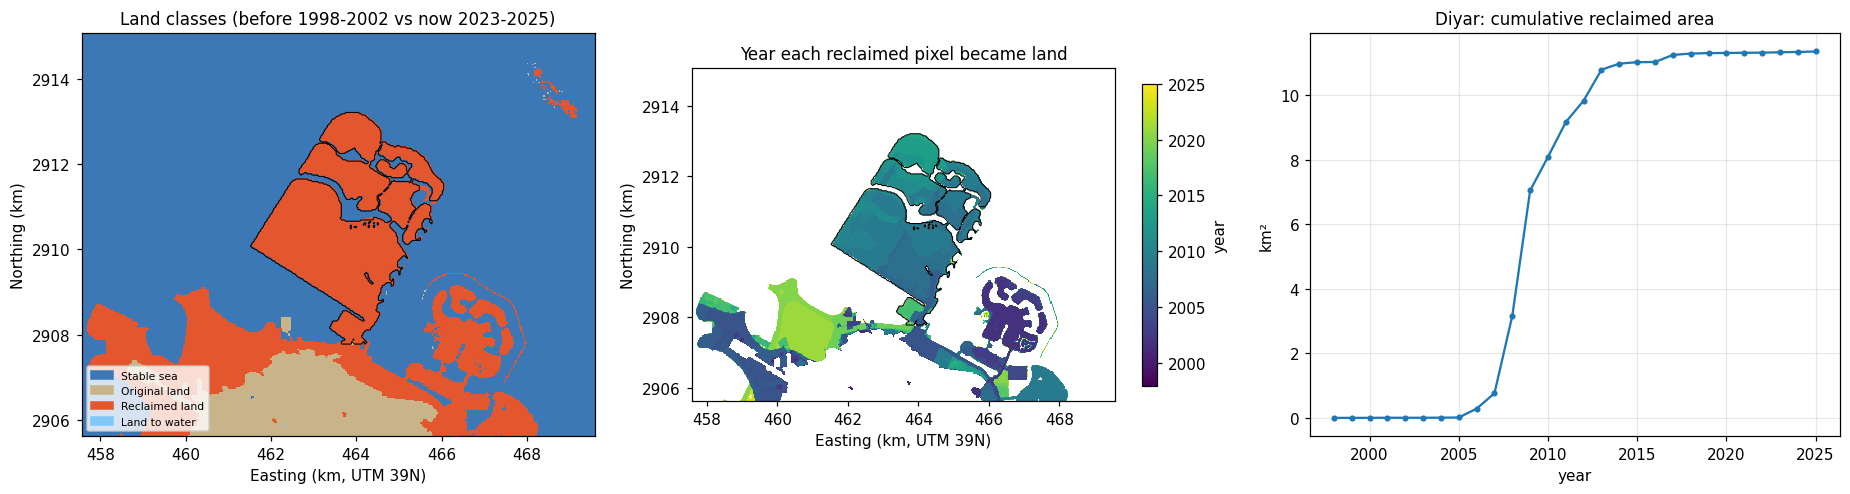

In [ ]:
def conversion_year(water_stack, years, min_land_share):
    land = np.where(np.isnan(water_stack), np.nan, 1 - water_stack)
    obs_after = np.cumsum(~np.isnan(land[::-1]), axis=0)[::-1]           # observed years from t onward
    land_after = np.cumsum(np.nan_to_num(land[::-1]), axis=0)[::-1]      # land years from t onward
    share = np.divide(land_after, obs_after, out=np.zeros_like(land_after, dtype=float), where=obs_after > 0)
    out = np.full(water_stack.shape[1:], np.nan)
    for t in range(len(years) - 1, -1, -1):                              # keep the earliest qualifying year
        ok = (share[t] >= min_land_share) & (land[t] == 1)
        out = np.where(ok, years[t], out)
    return out

conv_year = conversion_year(water_by_year, np.array(years_ok), CONVERSION_MIN_LAND_SHARE)
conv_year[~reclaimed] = np.nan
dy = conv_year[diyar]
reclamation_start = int(np.nanpercentile(dy, 5))
print(f"Diyar land creation: first 5% by {reclamation_start}, half by {int(np.nanmedian(dy))}, "
      f"95% by {int(np.nanpercentile(dy, 95))}")
if reclamation_start <= BASELINE_WATER_YEARS[1]:
    print("WARNING: some Diyar land appears before the end of the 'before' period; "
          "consider moving BASELINE_WATER_YEARS earlier.")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
cmap_cls = ListedColormap(["#3b78b5", "#c9b48a", "#e4572e", "#7fc8f8"])
show(axes[0], land_class, "Land classes (before 1998-2002 vs now 2023-2025)", cmap=cmap_cls,
     norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4), outline=diyar, cbar=False)
axes[0].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=cmap_cls(i)) for i in range(4)],
               labels=list(CLASS_NAMES.values()), loc="lower left", fontsize=7)
show(axes[1], conv_year, "Year each reclaimed pixel became land", cmap="viridis", outline=diyar, label="year")
yrs_axis = np.array(years_ok)
cum = [np.sum(dy <= y) * PX_AREA_KM2 for y in yrs_axis]
axes[2].plot(yrs_axis, cum, marker="o", ms=3)
axes[2].set_title("Diyar: cumulative reclaimed area")
axes[2].set_ylabel("km²"); axes[2].set_xlabel("year"); axes[2].grid(alpha=0.3)
plt.tight_layout(); save(fig, "q1_reclamation_history"); plt.show()

**What these maps show:** Left: red is land created from the sea since about 2000; Diyar is outlined in black. Middle: the year each reclaimed pixel became land, which shows the order in which the islands were built. Right: Diyar's land area over time.

The curve is flat until 2005, rises steeply from 2007, and levels off after 2013: **Diyar's land was created in about seven years, with 5% in place by 2007, half by 2009 and 95% by 2013.** The flat start confirms that the "before" years used next (up to 2006) really were before Diyar existed.

### 6.5 Distances to water and to reclaimed land

**What this does:** For every pixel, computes the distance to the nearest current water and the distance to the nearest reclaimed land (saved with the results).

**Why:** Distance to water is needed to (a) pick open-sea reference pixels well away from the shore, and (b) measure how far the sea's cooling reaches into the land, which decides which pixels are fair to compare in the hotspot ranking (Section 9.1).

In [ ]:
water_now_mask = np.nan_to_num(water_now, nan=0) >= 0.5
dist_to_water_m = ndimage.distance_transform_edt(~water_now_mask) * PIXEL_M
dist_to_land_m = ndimage.distance_transform_edt(water_now_mask) * PIXEL_M
dist_to_reclaimed_m = ndimage.distance_transform_edt(~reclaimed) * PIXEL_M

sea_ref = (land_class == SEA) & (dist_to_land_m >= SEA_REF_MIN_DIST_M)
print(f"Open-sea reference pixels: {sea_ref.sum():,}")
print(f"Diyar land pixels: {np.sum(diyar & ~water_now_mask):,}")
if sea_ref.sum() < 200:
    raise RuntimeError("Too few open-sea reference pixels; enlarge STUDY_BBOX or reduce SEA_REF_MIN_DIST_M.")

Open-sea reference pixels: 69,859
Diyar land pixels: 12,628


## 7. Q2: How much hotter did the reclaimed locations become?

### 7.1 Load recent summer surface temperature (Landsat 8 and 9, 2021 to 2025)

**What this does:** Loads every June to September Landsat 8 and 9 scene with less than 20% cloud, converts it to °C, removes cloudy pixels, and keeps only scenes that see at least 60% of Diyar clearly.

**What "surface temperature" means here:** The Level-2 product is the temperature of the ground surface itself (roof, sand, asphalt, water surface), corrected by USGS for the atmosphere and for how efficiently each material emits heat. It is not air temperature, and on a summer midday it is usually well above air temperature.

**When it is measured:** Landsat passes over Bahrain at about 10:30 to 11:00 local time. All results describe late-morning conditions, not the afternoon peak or the night.

In [ ]:
def summer_items(years, platforms, max_cloud):
    items = []
    for y in years:
        items += search_items("landsat-c2-l2", f"{y}-{SUMMER[0]}", f"{y}-{SUMMER[1]}",
                              max_cloud=max_cloud, platforms=platforms)
    return items

def load_lst(items):
    parts = []
    for key in sorted({thermal_band(it) for it in items}):
        group = [it for it in items if thermal_band(it) == key]
        ds = load(group, [key, "qa_pixel"], GBOX30)
        parts.append(to_celsius(ds[key]).where(landsat_clear(ds["qa_pixel"])).rename("lst"))
    lst = xr.concat(parts, dim="time").sortby("time")
    return lst.groupby("time").first() if lst.indexes["time"].has_duplicates else lst

def quality_filter(lst, region, label):
    vals = lst.values
    clear_frac = np.isfinite(vals[:, region]).mean(axis=1)
    sea_count = np.isfinite(vals[:, sea_ref]).sum(axis=1)
    keep = (clear_frac >= MIN_CLEAR_FRACTION) & (sea_count >= 100)
    log = pd.DataFrame({"date": pd.to_datetime(lst.time.values).date, "clear_share_of_area": clear_frac.round(2),
                        "sea_ref_pixels": sea_count, "used": keep})
    print(f"{label}: {keep.sum()} of {len(keep)} scene-days pass the quality filter")
    return lst.isel(time=np.where(keep)[0]), log

recent_items = require(summer_items(LST_RECENT_YEARS, ("landsat-8", "landsat-9"), LST_MAX_CLOUD),
                       "recent summer Landsat 8/9")
print(f"Found {len(recent_items)} candidate scenes")
lst_recent_all = load_lst(recent_items)
lst_recent, recent_log = quality_filter(lst_recent_all, diyar, "Recent summers")
if lst_recent.sizes["time"] < 5:
    raise RuntimeError("Fewer than 5 usable summer scenes; relax LST_MAX_CLOUD or MIN_CLEAR_FRACTION.")
display(recent_log.groupby(pd.to_datetime(recent_log["date"]).dt.year)["used"].agg(["sum", "count"])
        .rename(columns={"sum": "used", "count": "available"}).T)

Found 53 candidate scenes


  0%|          | 0/106 [00:00<?, ?it/s]

Recent summers: 52 of 53 scene-days pass the quality filter


date,2021,2022,2023,2024,2025
used,7,6,15,11,13
available,7,7,15,11,13


**What the output shows:** 53 Landsat 8 and 9 summer scenes were found for 2021 to 2025, and 52 passed the quality filter. 2023 has the most usable scenes and 2021 and 2022 the fewest, but every summer is represented.

### 7.1b Only count land after it exists

**What this does:** Parts of Diyar (for example the North Islands) were still being reclaimed during 2021 to 2025. In a 2021 image those pixels are still sea, and averaging them with later land-years would make the newest land look falsely cool. Using the year each pixel became land (Section 6.4), we remove every observation of a reclaimed pixel taken before that year.

In [ ]:
scene_year = xr.DataArray(np.asarray(pd.to_datetime(lst_recent.time.values).year), dims="time")
year_created = xr.DataArray(np.nan_to_num(conv_year, nan=0), dims=("y", "x"))   # non-reclaimed pixels: always valid
before = int(np.isfinite(lst_recent.values[:, diyar]).sum())
lst_recent = lst_recent.where(year_created <= scene_year)
after = int(np.isfinite(lst_recent.values[:, diyar]).sum())
print(f"Diyar observations removed because the land did not exist yet: {before - after:,} of {before:,} "
      f"({100 * (before - after) / max(before, 1):.1f}%)")

Diyar observations removed because the land did not exist yet: 1,146 of 656,654 (0.2%)


**What the output shows:** The printed share is small, because almost all of Diyar existed by 2013. The step matters mainly for any land still being completed.

### 7.2 Express each day relative to the open sea

**What this does:** For each scene, takes the median temperature of open-sea pixels at least 300 m from land and subtracts it from every pixel. The result, "°C above open sea", is comparable across days.

**Why:** Absolute temperature changes with each day's weather. The open Gulf in the same image on the same morning is a stable local reference, so the difference isolates what the surface itself is doing. It also makes old (Landsat 5) and new (Landsat 8/9) sensors comparable, because any calibration difference between them affects the sea and the land equally.

Open-sea reference over the used scenes: median 33.5 °C (range 28.4 to 36.0 °C)
Diyar land, median summer surface temperature: 47.6 °C


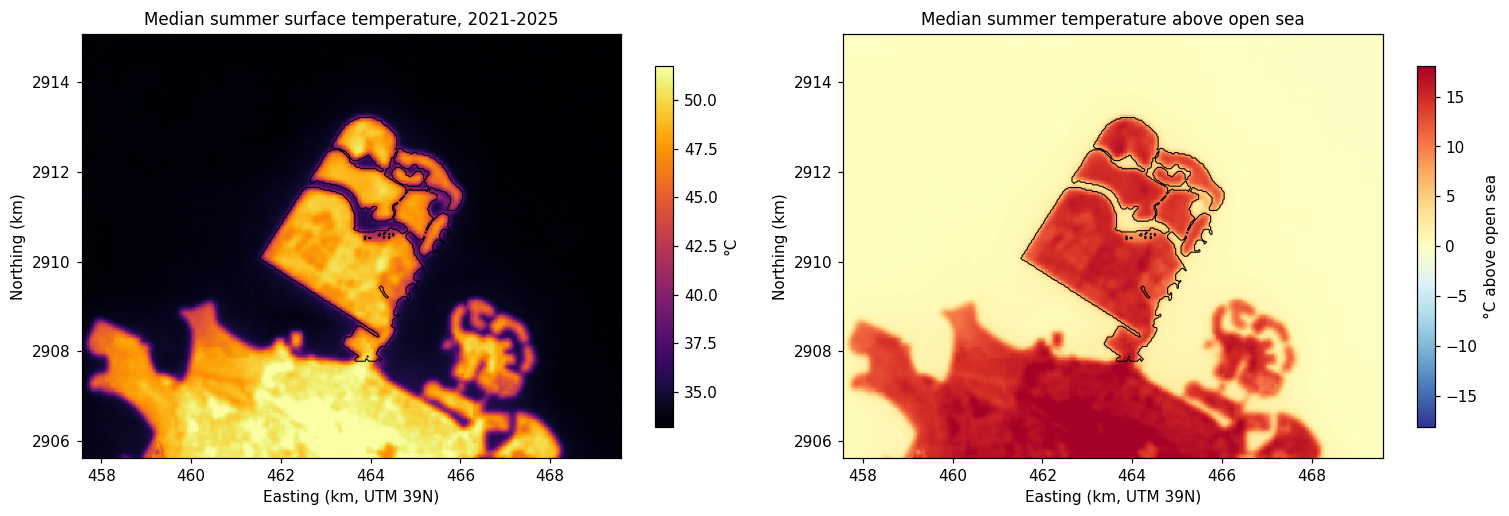

In [ ]:
def relative_to_sea(lst):
    ref = lst.where(xr.DataArray(sea_ref, dims=("y", "x"))).median(dim=("y", "x"), skipna=True)
    return lst - ref, ref

delta_recent, sea_recent = relative_to_sea(lst_recent)
lst_recent_median = lst_recent.median("time", skipna=True).values
delta_recent_median = delta_recent.median("time", skipna=True).values

print(f"Open-sea reference over the used scenes: median {float(sea_recent.median()):.1f} °C "
      f"(range {float(sea_recent.min()):.1f} to {float(sea_recent.max()):.1f} °C)")
print(f"Diyar land, median summer surface temperature: {np.nanmedian(lst_recent_median[diyar]):.1f} °C")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
show(axes[0], lst_recent_median, f"Median summer surface temperature, {LST_RECENT_YEARS[0]}-{LST_RECENT_YEARS[-1]}",
     cmap="inferno", vmin=np.nanpercentile(lst_recent_median, 2), vmax=np.nanpercentile(lst_recent_median, 98),
     label="°C", outline=diyar)
show(axes[1], delta_recent_median, "Median summer temperature above open sea", cmap="RdYlBu_r",
     vmin=-np.nanpercentile(np.abs(delta_recent_median), 98), vmax=np.nanpercentile(np.abs(delta_recent_median), 98),
     label="°C above open sea", outline=diyar)
plt.tight_layout(); save(fig, "q2_recent_summer_lst"); plt.show()

**What these maps show:** Left: the typical summer surface temperature at the satellite's late-morning pass. **Diyar's median is 47.6 °C** (most of Diyar lies between 40.9 and 49.8 °C). The older Muharraq land to the south is hotter still, with a median of 51.0 °C. The sea is the dark area.

Right: the same data as "°C above the open sea". All land stands 10 to 18 °C above the sea. The waterfront edges of Diyar are visibly less red than its interior, which Section 9.1 measures.

### 7.3 The "before" summers, when Diyar was still sea

**What this does:** Loads summer surface temperature from Landsat 5 and 7 for years *before* Diyar's land started to appear. The cut-off is not guessed: it uses the first year in which at least 5% of Diyar existed (found in Section 6.4), so no partly built years leak into "before". The same quality filter and the same open-sea correction are applied.

**Other reclaimed land started earlier** (from about 2002) than Diyar. So that its "before" value is not polluted by summers after it was built, each reclaimed pixel only contributes "before" observations from years before it became land.

**Note on resolution:** Landsat 5's thermal sensor sees about 120 m, slightly coarser than Landsat 8/9 (about 100 m). This blurs edges a little but does not bias averages over the whole development.

In [ ]:
baseline_years = [y for y in LST_BASELINE_CANDIDATE_YEARS if y < reclamation_start]
print(f"Diyar land starts appearing in {reclamation_start}; 'before' summers searched: "
      f"{baseline_years[0] if baseline_years else '-'} to {baseline_years[-1] if baseline_years else '-'}")
base_items = summer_items(baseline_years, ("landsat-5", "landsat-7"), LST_MAX_CLOUD) if baseline_years else []
HAVE_BASELINE = len(base_items) > 0
if HAVE_BASELINE:
    lst_base_all = load_lst(base_items)
    lst_base, base_log = quality_filter(lst_base_all, diyar, "Before summers")
    base_year = xr.DataArray(np.asarray(pd.to_datetime(lst_base.time.values).year), dims="time")
    became_land = xr.DataArray(np.nan_to_num(conv_year, nan=9999), dims=("y", "x"))  # not reclaimed: never
    lst_base = lst_base.where(base_year < became_land)
    HAVE_BASELINE = lst_base.sizes["time"] >= 3
if HAVE_BASELINE:
    delta_base, sea_base = relative_to_sea(lst_base)
    delta_base_median = delta_base.median("time", skipna=True).values
else:
    delta_base_median = np.full((NY, NX), np.nan)
    print("Not enough usable 'before' summers; the before/after comparison below will be skipped.")

Diyar land starts appearing in 2007; 'before' summers searched: 1995 to 2006


  0%|          | 0/148 [00:00<?, ?it/s]

Before summers: 74 of 74 scene-days pass the quality filter


**What the output shows:** 75 "before" summer scenes from 1995 to 2006 were found (56 from Landsat 5 and 19 from Landsat 7), and 74 passed the quality filter. That is more than enough to describe the location's summer temperature before Diyar existed.

### 7.4 Same place, before and after

**What this does:** For each group of pixels, compares the typical "°C above open sea" before reclamation and now:

- **Diyar reclaimed land**: the main result.
- **Other reclaimed land** in the box: a second, independent example of the same process.
- **Original land**: land in both periods. Its change reflects ordinary urban growth and any small difference between old and new satellites; it is the background change that is *not* caused by reclamation.
- **Stable sea**: should change by about 0. If it does, the comparison between satellites is trustworthy.

**Why this is the right measurement:** It compares the same ground, in the same season, against the same reference, before and after. The extra warming of Diyar *beyond* the original-land change is the part that can be attributed to turning sea into land.

,pixels,before_°C_above_sea,now_°C_above_sea,change_°C
group,,,,
Diyar reclaimed land,12628,0.00,13.970000,13.97
Other reclaimed land,15459,0.14,14.060000,13.92
Original land,8972,14.46,17.139999,2.69
Stable sea,89254,0.00,0.030000,0.03


Diyar's location warmed by 14.0 °C relative to the open sea between the 'before' and 'now' summers.
Original land changed by +2.7 °C over the same period (background change).
Warming attributable to converting sea to land: about 11.3 °C.
Sensor consistency check, stable sea change: +0.03 °C (good)


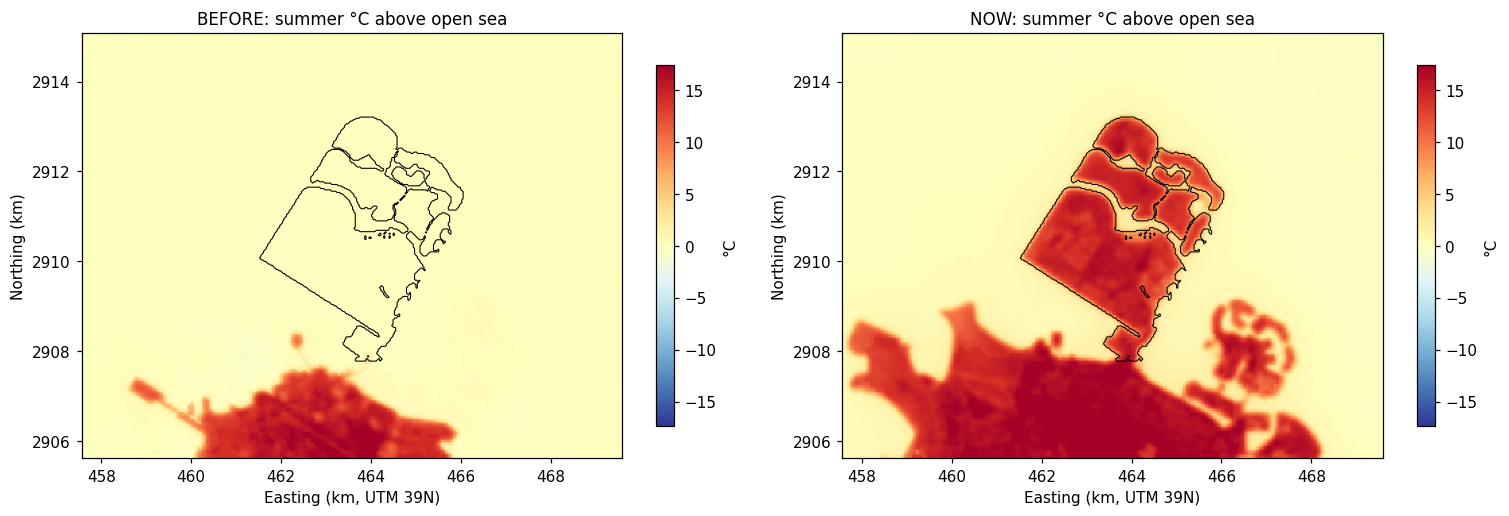

In [ ]:
groups = {"Diyar reclaimed land": diyar, "Other reclaimed land": other_reclaimed,
          "Original land": land_class == LAND, "Stable sea": land_class == SEA}
rows = []
for name, m in groups.items():
    if m.sum() == 0:
        continue
    before = np.nanmedian(delta_base_median[m]) if HAVE_BASELINE else np.nan
    now = np.nanmedian(delta_recent_median[m])
    rows.append({"group": name, "pixels": int(m.sum()), "before_°C_above_sea": round(before, 2),
                 "now_°C_above_sea": round(now, 2), "change_°C": round(now - before, 2)})
before_after = pd.DataFrame(rows).set_index("group")
display(before_after)

if HAVE_BASELINE:
    d_change = before_after.loc["Diyar reclaimed land", "change_°C"]
    bg_change = before_after.loc["Original land", "change_°C"]
    sea_change = before_after.loc["Stable sea", "change_°C"]
    attributable = d_change - bg_change
    print(f"Diyar's location warmed by {d_change:.1f} °C relative to the open sea between the 'before' and 'now' summers.")
    print(f"Original land changed by {bg_change:+.1f} °C over the same period (background change).")
    print(f"Warming attributable to converting sea to land: about {attributable:.1f} °C.")
    print(f"Sensor consistency check, stable sea change: {sea_change:+.2f} °C "
          f"({'good' if abs(sea_change) < 1 else 'larger than 1 °C, treat the before/after numbers with caution'})")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    lim = np.nanpercentile(np.abs(np.r_[delta_base_median[np.isfinite(delta_base_median)],
                                         delta_recent_median[np.isfinite(delta_recent_median)]]), 98)
    show(axes[0], delta_base_median, "BEFORE: summer °C above open sea", cmap="RdYlBu_r", vmin=-lim, vmax=lim,
         label="°C", outline=diyar)
    show(axes[1], delta_recent_median, "NOW: summer °C above open sea", cmap="RdYlBu_r", vmin=-lim, vmax=lim,
         label="°C", outline=diyar)
    plt.tight_layout(); save(fig, "q2_before_after"); plt.show()

**What the table and maps show:**

| Area | Before (°C above open sea) | Now (°C above open sea) | Change |
|---|---|---|---|
| Diyar reclaimed land | 0.0 | +14.0 | **+14.0 °C** |
| Other reclaimed land | +0.1 | +14.1 | +13.9 °C |
| Original land | +14.5 | +17.1 | +2.7 °C |
| Stable sea | 0.0 | 0.0 | +0.03 °C |

- **Before reclamation, Diyar's location had exactly the temperature of the open sea.** In the left map, the Diyar outline sits on sea-coloured water. In the right map, the same outline is filled with deep red.
- **Original land warmed by 2.7 °C** over the same period, through urban growth, climate and any small sensor difference. Subtracting it leaves **about 11.3 °C of summer surface warming caused by turning sea into land.**
- **The other reclaimed land shows the same jump (+13.9 °C)**, so this is not unique to Diyar; it is what reclamation does.
- **The open sea changed by only 0.03 °C** between the old and new satellites, so the before/after comparison is reliable.

## 8. Q4 (prepared first): What surface covers each pixel?

We build the surface layers before detecting hotspots so the hotspots can be explained as soon as they are found.

### 8.1 Sentinel-2: vegetation and water at 10 m (summer 2025)

**What this does:** Loads the 12 clearest Sentinel-2 scenes of summer 2025, removes cloud and shadow using Sentinel-2's own scene classification band (SCL), and computes the per-pixel median of:
- **NDVI** = (NIR − Red) / (NIR + Red), which is high for living vegetation
- **MNDWI** (as before), for water at 10 m

A 10 m pixel counts as vegetation if NDVI > 0.25. Each 30 m cell then gets the *share* of its nine 10 m pixels that are vegetation or water, for example "30% vegetated".

**Why Sentinel-2:** At 10 m it sees individual parks, planted strips and canals that Landsat's 30 m blurs. It has no thermal sensor, which is why temperature still comes from Landsat.

**Processing-baseline offset:** Sentinel-2 scenes processed from January 2022 onward store reflectance with an added offset of 1000. We read each scene's processing baseline from its catalogue record and subtract the offset where it applies.

In [ ]:
s2_items = require(search_items("sentinel-2-l2a", f"{S2_YEAR}-{SUMMER[0]}", f"{S2_YEAR}-{SUMMER[1]}",
                                max_cloud=S2_MAX_CLOUD), "Sentinel-2 summer scenes")
s2_items = sorted(s2_items, key=lambda it: it.properties.get("eo:cloud_cover", 100))[:S2_MAX_SCENES]
s2_items = sorted(s2_items, key=item_date)
display(describe(s2_items))

offset_by_day = {}
for it in s2_items:
    baseline = float(it.properties.get("s2:processing_baseline", "0") or 0)
    offset_by_day[item_date(it).date()] = 1000 if baseline >= 4.0 else 0

s2 = load(s2_items, ["B02", "B03", "B04", "B08", "B11", "SCL"], GBOX10,
          resampling={"B11": "bilinear", "*": "nearest"})
offsets = xr.DataArray([offset_by_day.get(pd.Timestamp(t).date(), 0) for t in s2.time.values], dims="time")
valid_scl = s2["SCL"].isin([4, 5, 6, 7, 11])    # vegetation, bare, water, unclassified, bright surfaces

def s2_refl(band):
    dn = s2[band].astype("float32")
    return xr.where(dn > 0, (dn - offsets) / 10000.0, np.nan).clip(min=1e-4).where(valid_scl)

red, green, blue, nir, swir = (s2_refl(b) for b in ["B04", "B03", "B02", "B08", "B11"])
ndvi10 = ((nir - red) / (nir + red)).median("time", skipna=True).values
mndwi10 = ((green - swir) / (green + swir)).median("time", skipna=True).values
rgb10 = np.dstack([red.median("time").values, green.median("time").values, blue.median("time").values])

def to30(arr10):
    return np.nanmean(arr10.reshape(NY, 3, NX, 3), axis=(1, 3))

veg10 = np.where(np.isfinite(ndvi10), (ndvi10 > VEG_NDVI_THRESHOLD).astype("float32"), np.nan)
wat10 = np.where(np.isfinite(mndwi10), (mndwi10 > WATER_MNDWI_THRESHOLD).astype("float32"), np.nan)
frac_veg = to30(veg10)
frac_water_s2 = to30(wat10)
ndvi30 = to30(ndvi10)
print(f"Sentinel-2 offsets applied (by day): {sorted(set(offset_by_day.values()))}")
print(f"Diyar land: {100 * np.nanmean(frac_veg[diyar & ~water_now_mask]):.1f}% vegetated at 10 m detail")

,date,satellite,cloud_%,scene_id
0,2025-06-07,Sentinel-2C,0.1,S2C_MSIL2A_20250607T070641_R106_T39RVK_2025060...
1,2025-06-09,Sentinel-2A,0.1,S2A_MSIL2A_20250609T071321_R106_T39RVK_2025060...
2,2025-06-12,Sentinel-2B,0.1,S2B_MSIL2A_20250612T070619_R106_T39RVK_2025061...
3,2025-06-17,Sentinel-2C,0.1,S2C_MSIL2A_20250617T070641_R106_T39RVK_2025061...
4,2025-07-02,Sentinel-2B,0.1,S2B_MSIL2A_20250702T070629_R106_T39RVK_2025070...
5,2025-07-17,Sentinel-2C,0.1,S2C_MSIL2A_20250717T070651_R106_T39RVK_2025071...
6,2025-08-06,Sentinel-2C,0.1,S2C_MSIL2A_20250806T070641_R106_T39RVK_2025080...
7,2025-08-16,Sentinel-2C,0.2,S2C_MSIL2A_20250816T070641_R106_T39RVK_2025081...
8,2025-08-21,Sentinel-2B,0.1,S2B_MSIL2A_20250821T070629_R106_T39RVK_2025082...
9,2025-09-10,Sentinel-2B,0.0,S2B_MSIL2A_20250910T070619_R106_T39RVK_2025091...


  0%|          | 0/72 [00:00<?, ?it/s]

Sentinel-2 offsets applied (by day): [1000]
Diyar land: 0.7% vegetated at 10 m detail


**What the output shows:** 12 clear Sentinel-2 scenes from June to September 2025 were used. Inside Diyar, vegetation is almost absent: under 1% of the land has NDVI above 0.25.

### 8.2 Land cover map: built-up versus bare ground (10 m)

**What this does:** Loads the Impact Observatory / Esri annual 10 m land cover map (the latest year available, 2023) and turns its classes into four shares per 30 m cell: built area, bare ground, vegetation (trees, grass and shrubland, crops), and water.

**Why we need it:** The usual built-up index (NDBI) cannot tell dry sand from concrete in a desert: both reflect shortwave infrared strongly. On reclaimed land this matters, because much of it is bare fill waiting to be built on. This map was produced by a model trained on labelled examples, so it does separate "built" from "bare". Its limitation is age: areas built in 2024 and 2025 will still show as bare. We note this wherever it affects conclusions.

In [ ]:
lulc_items = require(search_items("io-lulc-annual-v02", "2017-01-01", "2024-12-31"), "the 10 m land cover map")
latest = max(item_date(it).year for it in lulc_items)
lulc_items = [it for it in lulc_items if item_date(it).year == latest]
print(f"Land cover year used: {latest} ({len(lulc_items)} tile(s))")

template10 = xr.DataArray(np.zeros((3 * NY, 3 * NX), dtype="uint8"),
                          coords={"y": T30.f - (np.arange(3 * NY) + 0.5) * 10,
                                  "x": T30.c + (np.arange(3 * NX) + 0.5) * 10},
                          dims=("y", "x")).rio.write_crs(CRS)
lulc10 = np.zeros((3 * NY, 3 * NX), dtype="uint8")
for it in lulc_items:
    da = rioxarray.open_rasterio(planetary_computer.sign(it.assets["data"].href)).squeeze(drop=True)
    da = da.rio.clip_box(*STUDY_BBOX, crs="EPSG:4326")
    da = da.rio.reproject_match(template10, resampling=Resampling.nearest).values.astype("uint8")
    lulc10 = np.where(lulc10 == 0, da, lulc10)   # 0 = no data; fill from each tile in turn

LULC_GROUPS = {"built": [7], "bare": [8], "vegetation_lulc": [2, 4, 5, 11], "water_lulc": [1]}
valid10 = (lulc10 > 0) & (lulc10 != 10)        # 10 = cloud
frac = {}
for name, codes in LULC_GROUPS.items():
    frac[name] = to30(np.where(valid10, np.isin(lulc10, codes).astype("float32"), np.nan))

counts = pd.Series(lulc10[np.repeat(np.repeat(diyar, 3, 0), 3, 1)]).value_counts()
names = {1: "Water", 2: "Trees", 4: "Flooded vegetation", 5: "Crops", 7: "Built area", 8: "Bare ground",
         10: "Clouds", 11: "Rangeland", 0: "No data"}
display((100 * counts / counts.sum()).round(1).rename(index=names).to_frame(f"% of Diyar ({latest})"))

Land cover year used: 2023 (1 tile(s))


,% of Diyar (2023)
Bare ground,64.2
Built area,29.3
Water,6.5
Rangeland,0.0


**What the output shows:** In the 2023 land cover map, Diyar is about two thirds bare ground and just under one third built area, with a few percent water (canals and edges) and almost no trees, grass or shrubland. A large part of the development was still unbuilt fill in 2023.

### 8.3 Look at the site

**What this does:** Shows the Sentinel-2 natural-colour image with Diyar outlined, next to the land cover map and the vegetation share. This is the visual check that the automatically selected area really is Diyar and that the surface layers match what can be seen.

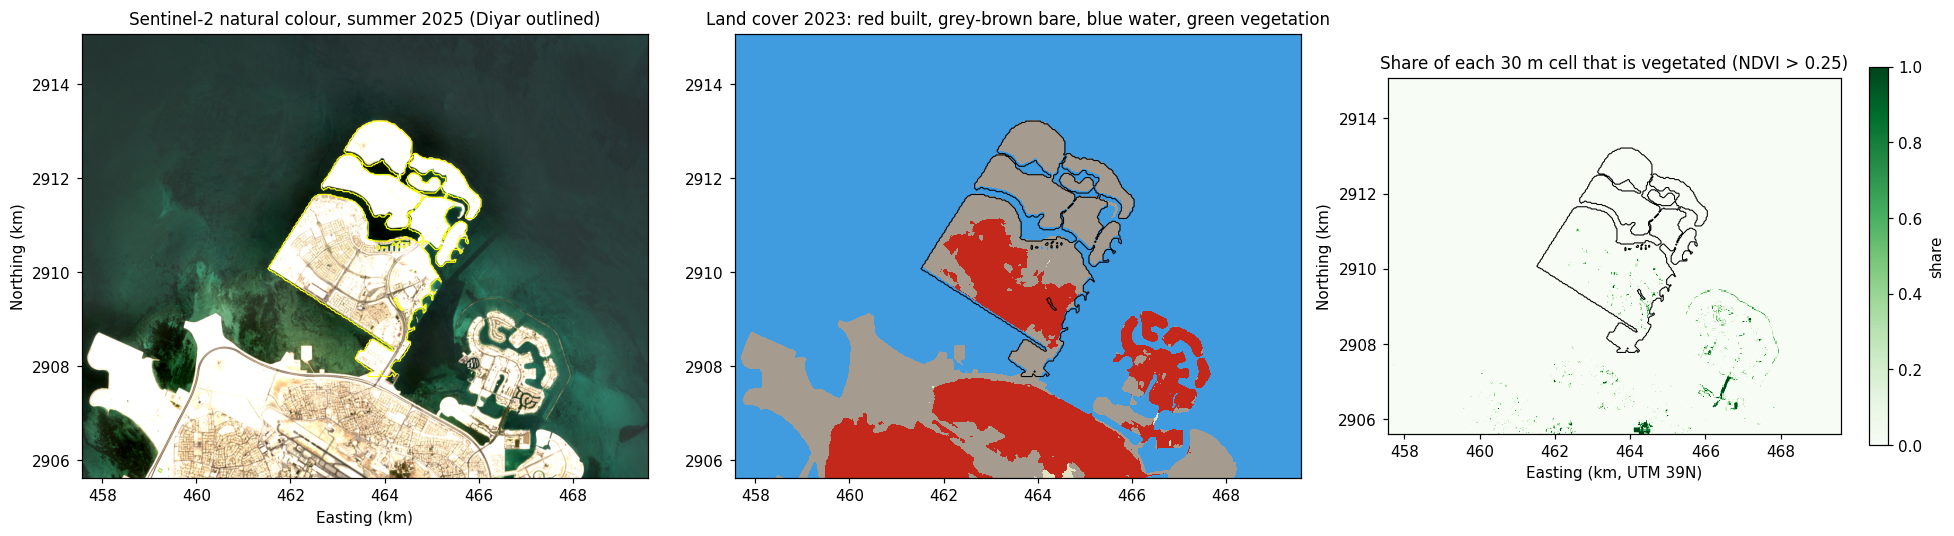

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(np.clip(rgb10 / 0.3, 0, 1), extent=EXTENT_KM, origin="upper")
axes[0].contour(diyar.astype(float), levels=[0.5], colors="yellow", linewidths=0.8, extent=EXTENT_KM, origin="upper")
axes[0].set_title(f"Sentinel-2 natural colour, summer {S2_YEAR} (Diyar outlined)")
axes[0].set_xlabel("Easting (km)"); axes[0].set_ylabel("Northing (km)")

lulc_cmap = ListedColormap(["#ffffff", "#419bdf", "#397d49", "#ffffff", "#7a87c6", "#e49635", "#ffffff",
                            "#c4281b", "#a59b8f", "#a8ebff", "#616161", "#e3e2c3"])
axes[1].imshow(lulc10, extent=EXTENT_KM, origin="upper", cmap=lulc_cmap, vmin=-0.5, vmax=11.5,
               interpolation="nearest")
axes[1].contour(diyar.astype(float), levels=[0.5], colors="black", linewidths=0.7, extent=EXTENT_KM, origin="upper")
axes[1].set_title(f"Land cover {latest}: red built, grey-brown bare, blue water, green vegetation")
show(axes[2], frac_veg, "Share of each 30 m cell that is vegetated (NDVI > 0.25)", cmap="Greens",
     vmin=0, vmax=1, label="share", outline=diyar)
plt.tight_layout(); save(fig, "q4_site_overview"); plt.show()

**What these maps show:** The natural-colour image (left) confirms the automatic outline matches Diyar's islands. Built neighbourhoods fill the southern half of the main island, while the northern islands are mostly empty, pale fill. The land cover map (middle) agrees: red (built) in the south of the main island, grey-brown (bare) elsewhere. The vegetation map (right) is almost blank inside Diyar; only thin lines along a few roads and the waterfront register as green.

## 9. Q3: Where inside Diyar are the persistent hotspots?

### 9.1 How far does the sea's cooling reach into the land?

**What this does:** Groups Diyar land by distance from the nearest water (0-30 m, 30-60 m, and so on) and plots how much each group's typical summer surface temperature differs from Diyar's median.

**Why it matters for hotspots:** If waterfront land is much cooler than inland land, a ranking of all of Diyar would simply say "inland is hot, waterfront is cool". That is a map of distance from the water, not of surfaces a developer can change. So we measure where the cooling fades and leave land closer than that out of the hotspot ranking. The distance is measured from the data (where the temperature gets within 0.5 °C of Diyar's interior level), so the same code works for other sites.

**Two effects combined:** Within roughly the first 100 m, the thermal sensor's footprint partly covers the sea, so part of the apparent cooling is a measurement effect. Beyond that the remaining gradient is a real cooling influence of the water (for example sea breezes and moister ground). The profile cannot separate the two exactly; it still shows how wide the waterfront band behaves differently.

Land right at the water (0-30 m) differs from Diyar's interior (> 450 m from water) by -7.5 °C.
The cooling fades within about 180 m; land closer than this is left out of the hotspot ranking.
Inland Diyar land used for ranking: 6,325 pixels (50% of Diyar land)


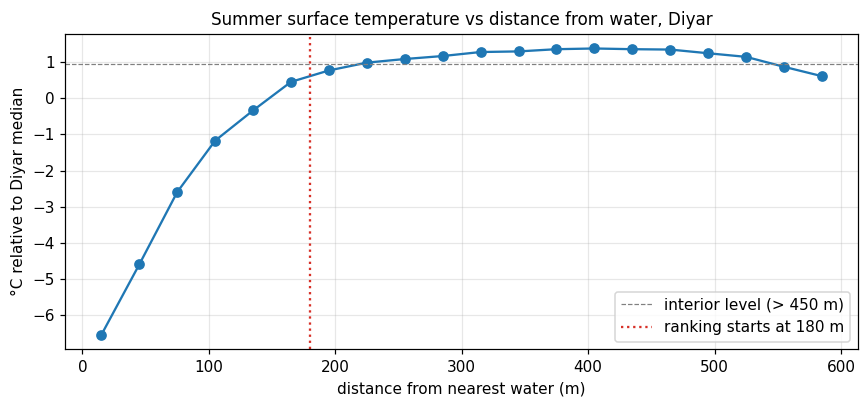

In [ ]:
land_d = diyar & ~water_now_mask & np.isfinite(lst_recent_median)
diyar_med = np.nanmedian(lst_recent_median[land_d])
edges = np.arange(0, 630, 30)
rows = []
for a, b in zip(edges[:-1], edges[1:]):
    sel = land_d & (dist_to_water_m > a) & (dist_to_water_m <= b)
    if sel.sum() >= 30:
        rows.append({"from_m": int(a), "to_m": int(b), "pixels": int(sel.sum()),
                     "vs_diyar_median_c": float(np.nanmedian(lst_recent_median[sel]) - diyar_med)})
coast_profile = pd.DataFrame(rows)
interior = land_d & (dist_to_water_m > 450)
plateau = (float(np.nanmedian(lst_recent_median[interior]) - diyar_med) if interior.sum() >= 100
           else float(coast_profile["vs_diyar_median_c"].max()))
if SHORE_BUFFER_M == "auto":
    reached = coast_profile[coast_profile["vs_diyar_median_c"] >= plateau - 0.5]
    shore_buffer = int(np.clip(reached["from_m"].min() if len(reached) else SHORE_BUFFER_LIMITS_M[1],
                               *SHORE_BUFFER_LIMITS_M))
else:
    shore_buffer = int(SHORE_BUFFER_M)
coastal_drop = plateau - coast_profile.iloc[0]["vs_diyar_median_c"]

diyar_core = diyar & ~water_now_mask & (dist_to_water_m >= shore_buffer)
print(f"Land right at the water (0-30 m) differs from Diyar's interior (> 450 m from water) by {-coastal_drop:+.1f} °C.")
print(f"The cooling fades within about {shore_buffer} m; land closer than this is left out of the hotspot ranking.")
print(f"Inland Diyar land used for ranking: {diyar_core.sum():,} pixels "
      f"({100 * diyar_core.sum() / land_d.sum():.0f}% of Diyar land)")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot((coast_profile["from_m"] + coast_profile["to_m"]) / 2, coast_profile["vs_diyar_median_c"], marker="o")
ax.axhline(plateau, color="grey", ls="--", lw=0.8, label="interior level (> 450 m)")
ax.axvline(shore_buffer, color="#d73027", ls=":", label=f"ranking starts at {shore_buffer} m")
ax.set_xlabel("distance from nearest water (m)"); ax.set_ylabel("°C relative to Diyar median")
ax.set_title("Summer surface temperature vs distance from water, Diyar"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); save(fig, "q3_coastal_cooling"); plt.show()

**What this graph shows:** Land within 30 m of the water is **6.6 °C cooler than Diyar's median and 7.5 °C cooler than its interior**. The temperature rises steadily with distance and comes within 0.5 °C of the interior level at **180 m**. From about 240 m inland, it stays roughly flat at 1.0 to 1.4 °C above the median. The slight dip beyond 540 m is based on few pixels (the centre of the main island) and should not be over-read.

**Why this changes the analysis:** About **half of Diyar's land lies within 180 m of water**, because its islands and canals give it a long shoreline. If this band were ranked together with the interior, every "cool cluster" would simply be a waterfront. So the hotspot ranking below covers the inland half only, and waterfront cooling is reported as a finding in its own right.

### 9.2 Move to 90 m cells and compute each day's anomalies

**What this does:** Groups the 30 m pixels into 90 m cells (3 by 3 pixels), averaging only the inland Diyar pixels in each. A cell is analysed if at least 5 of its 9 pixels are inland Diyar land. Then, for every clear summer scene:
1. **Excess (°C)**: each cell's temperature minus Diyar's median that day. Easy to explain: "this block is typically 2 °C hotter than the rest of Diyar".
2. **Standardised anomaly (z)**: the excess divided by that day's spread, so days with stronger contrasts do not dominate.
3. **Hot that day**: whether the cell is among Diyar's hottest 10% that day.

Across all scenes we keep the average excess, the average z, and the **persistence**: the share of clear scenes in which the cell was among the hottest 10%.

**Why 90 m cells:** The thermal sensor sees about 100 m. At 30 m, neighbouring pixels are copies of overlapping measurements, so a statistical test treats one real measurement as nine and becomes far too confident. Tested at 30 m, the hotspot test flags around three quarters of Diyar as "significant", which is not a believable result. At 90 m each cell is close to one independent measurement.

**Why relative to Diyar itself:** The developer's question is "which parts of *my* development run hottest". Comparing within Diyar answers that directly and removes the day's weather.

In [ ]:
F = CELL_M // PIXEL_M
NYc, NXc = NY // F, NX // F
CELL_HA = CELL_M ** 2 / 1e4

def to_cells(a):
    a = np.asarray(a, dtype="float64")[:NYc * F, :NXc * F]
    return np.nanmean(a.reshape(NYc, F, NXc, F), axis=(1, 3))

def to_pixels(a):
    out = np.full((NY, NX), np.nan, dtype="float32")
    out[:NYc * F, :NXc * F] = np.repeat(np.repeat(np.asarray(a, dtype="float32"), F, 0), F, 1)
    return out

cell_ok = to_cells(diyar_core.astype(float)) >= MIN_CORE_SHARE
core_da = xr.DataArray(diyar_core, dims=("y", "x"))
cell_da = xr.DataArray(cell_ok, dims=("y", "x"))

def cell_stack(lst_stack):
    s = lst_stack.where(core_da).isel(y=slice(0, NYc * F), x=slice(0, NXc * F))
    return s.coarsen(y=F, x=F).mean().where(cell_da)

def cell_anomalies(lst_stack, pct=HOT_PERCENTILE):
    C = cell_stack(lst_stack)
    med = C.median(dim=("y", "x"), skipna=True)
    excess = C - med
    z = excess / C.std(dim=("y", "x"), skipna=True)
    hot = (C >= C.quantile(pct / 100, dim=("y", "x"), skipna=True)).where(np.isfinite(C))
    n = np.isfinite(C.values).sum(axis=0)
    min_obs = max(3, int(0.3 * C.sizes["time"]))   # 30% of the scenes in this stack
    ok = cell_ok & (n >= min_obs)
    return {"excess": np.where(ok, excess.mean("time").values, np.nan),
            "z": np.where(ok, z.mean("time").values, np.nan),
            "freq": np.where(ok, hot.mean("time").values, np.nan),
            "n_obs": n, "rank": ok, "min_obs": min_obs}

A = cell_anomalies(lst_recent)
rank_c = A["rank"]
print(f"Scenes used: {lst_recent.sizes['time']}. Cells ranked: {rank_c.sum():,} of {CELL_M} m "
      f"({rank_c.sum() * CELL_HA:.0f} ha), each seen clearly in at least {A['min_obs']} scenes")
print(f"Spread of average excess between Diyar cells: 5th percentile {np.nanpercentile(A['excess'][rank_c], 5):+.1f} °C, "
      f"95th percentile {np.nanpercentile(A['excess'][rank_c], 95):+.1f} °C")

Scenes used: 52. Cells ranked: 698 of 90 m (565 ha), each seen clearly in at least 15 scenes
Spread of average excess between Diyar cells: 5th percentile -1.6 °C, 95th percentile +1.2 °C


**What the output shows:** 698 inland cells (565 ha) are ranked, each seen clearly in many summer scenes. Inside Diyar's interior, cells differ by only a few degrees: most cells are between about 1.5 °C below and 1.2 °C above Diyar's median on a typical summer morning.

### 9.3 The spatial hotspot test (Getis-Ord Gi\*)

**What it does, in plain words:** For every cell, Gi\* adds up the values of the cell and its 8 touching neighbours and asks: is this neighbourhood's total much higher (or lower) than would be expected if values were scattered at random across Diyar? The answer is a z-score with a p-value.

**Formula:** For cell *i* with neighbours *j* (including itself), *n* ranked cells, mean x̄, standard deviation *S*, and *W_i* neighbours:

$$G_i^* = \frac{\sum_j x_j - \bar{x}\,W_i}{S\sqrt{\dfrac{n\,W_i - W_i^2}{n-1}}}$$

**Correcting for testing many cells at once:** With several hundred cells tested, some would pass a 95% test by chance alone. We use the Benjamini-Hochberg false discovery rate (FDR) correction, the approach usually recommended for local hotspot statistics: among the cells flagged, at most about 5% are expected to be false alarms.

**The classes:**
- **Hotspot**: neighbourhood significantly hot after the FDR correction, *and* the cell itself is above Diyar's median (a cell at the edge of a hot cluster is not flagged unless it is hot itself).
- **Persistent hotspot**: a hotspot that was also among Diyar's hottest 10% in at least half of all clear summer scenes.
- **Cool cluster**: the mirror image.

**Validation of the implementation:** The calculation uses a fast moving-window method. It was compared with the reference implementation in the PySAL library (`esda.G_Local`) on test data, and the results matched to 14 decimal places.

In [ ]:
def disk_kernel(radius_cells):
    r = int(np.ceil(radius_cells))
    yy, xx = np.mgrid[-r:r + 1, -r:r + 1]
    return (xx ** 2 + yy ** 2 <= radius_cells ** 2).astype(float)

def getis_ord_gi_star(values, valid, radius_m, cell_m=CELL_M):
    x = np.where(valid, values, 0.0).astype(float)
    v = valid.astype(float)
    n = v.sum()
    xbar = x.sum() / n
    s = np.sqrt((x[valid] ** 2).sum() / n - xbar ** 2)
    k = disk_kernel(radius_m / cell_m)
    w = ndimage.convolve(v, k, mode="constant")
    num = ndimage.convolve(x, k, mode="constant") - xbar * w
    den = s * np.sqrt((n * w - w ** 2) / (n - 1))
    z = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)
    z[~valid] = np.nan
    return z

def fdr_significant(z, valid, q=FDR_Q):
    p = 2 * stats.norm.sf(np.abs(z[valid]))
    order = np.argsort(p)
    passed = p[order] <= q * np.arange(1, p.size + 1) / p.size
    k = np.max(np.where(passed)[0]) + 1 if passed.any() else 0
    sig = np.zeros(p.size, bool); sig[order[:k]] = True
    out = np.zeros(z.shape, bool); out[valid] = sig
    return out

def hotspot_classes(anom, radius_m=GI_RADIUS_M):
    valid = anom["rank"] & np.isfinite(anom["z"])
    gi = getis_ord_gi_star(anom["z"], valid, radius_m)
    sig = fdr_significant(gi, valid)
    c = np.where(valid, 0.0, np.nan)
    c[sig & (gi < 0) & (anom["z"] < 0)] = -1
    c[sig & (gi > 0) & (anom["z"] > 0)] = 1
    c[(c == 1) & (anom["freq"] >= PERSISTENT_MIN_SHARE)] = 2
    return gi, sig, c

gi_c, sig_c, hot_c = hotspot_classes(A)
HOT_NAMES = {-1: "Cool cluster", 0: "Not significant", 1: "Hotspot", 2: "Persistent hotspot"}
counts = pd.Series({HOT_NAMES[k]: int(np.sum(hot_c == k)) for k in HOT_NAMES})
hotspot_table = pd.DataFrame({"cells": counts, "area_ha": (counts * CELL_HA).round(1),
                              "% of ranked Diyar": (100 * counts / rank_c.sum()).round(1)})
display(hotspot_table)
uncorrected = np.mean(np.abs(gi_c[rank_c]) > 1.96)
print(f"Share of cells significant without the FDR correction: {100 * uncorrected:.0f}%; "
      f"with it: {100 * sig_c[rank_c].mean():.0f}%")

# for display and export: back to 30 m pixels, shown only on inland Diyar land
def on_core(a):
    return np.where(diyar_core, to_pixels(a), np.nan)
hot_class = on_core(hot_c)
excess_c, hot_freq, gi_z = on_core(A["excess"]), on_core(A["freq"]), on_core(gi_c)
rank_mask = diyar_core & np.isfinite(hot_class)

,cells,area_ha,% of ranked Diyar
Cool cluster,121,98.0,17.3
Not significant,453,366.9,64.9
Hotspot,82,66.4,11.7
Persistent hotspot,42,34.0,6.0


Share of cells significant without the FDR correction: 47%; with it: 35%


**What the output shows:**

| Class | Area | Share of ranked inland Diyar |
|---|---|---|
| Persistent hotspot | 34 ha | 6% |
| Hotspot | 66 ha | 12% |
| Not significant | 367 ha | 65% |
| Cool cluster | 98 ha | 17% |

Without the multiple-testing correction, 47% of cells would be flagged as significant; with it, 35%. That share is still high because the temperature pattern inside Diyar really is organised at a large scale (a warm centre, cooler western and eastern parts), so many cells lie inside genuinely warm or cool areas. This is why the robustness checks in Section 9.5 define a "stable core" as the most reliable result.

### 9.4 Hotspot maps

**What this shows:** Left: average summer excess over Diyar's median. Middle: persistence, the share of summer scenes in which each cell was among Diyar's hottest 10%. Right: the final classes. Inside the outline, blank land is the waterfront band left out of the ranking (Section 9.1).

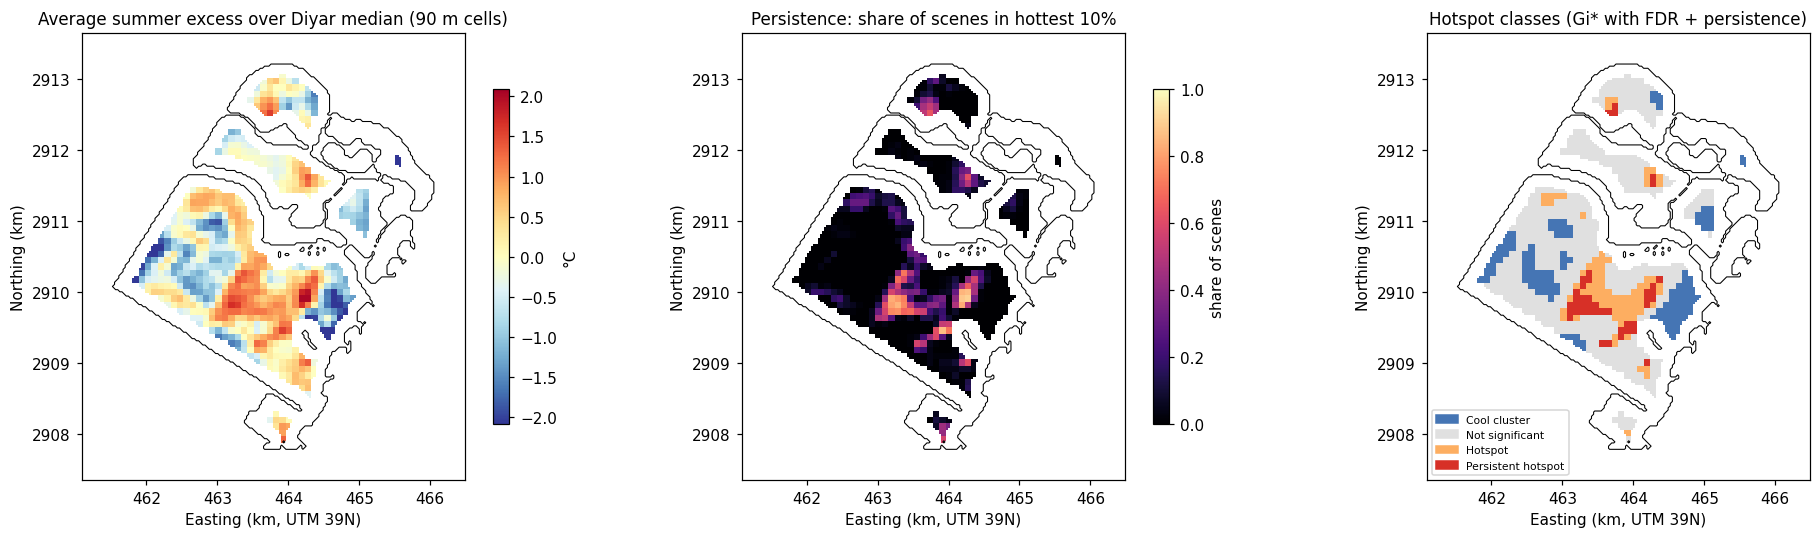

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lim = np.nanpercentile(np.abs(excess_c[rank_mask]), 98)
show(axes[0], excess_c, "Average summer excess over Diyar median (90 m cells)",
     cmap="RdYlBu_r", vmin=-lim, vmax=lim, label="°C", outline=diyar)
show(axes[1], hot_freq, f"Persistence: share of scenes in hottest {100 - HOT_PERCENTILE}%",
     cmap="magma", vmin=0, vmax=1, label="share of scenes", outline=diyar)
cls_cmap = ListedColormap(["#4575b4", "#e0e0e0", "#fdae61", "#d73027"])
show(axes[2], hot_class, "Hotspot classes (Gi* with FDR + persistence)", cmap=cls_cmap,
     norm=BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5], 4), outline=diyar, cbar=False)
axes[2].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=cls_cmap(i)) for i in range(4)],
               labels=list(HOT_NAMES.values()), loc="lower left", fontsize=7)
rr, cc = np.where(diyar)
for ax in axes:   # zoom to Diyar
    pad = 15
    ax.set_xlim(xs[max(cc.min() - pad, 0)] / 1000, xs[min(cc.max() + pad, NX - 1)] / 1000)
    ax.set_ylim(ys[min(rr.max() + pad, NY - 1)] / 1000, ys[max(rr.min() - pad, 0)] / 1000)
plt.tight_layout(); save(fig, "q3_hotspots"); plt.show()

**What these maps show:**
- **Hotspots form one large connected area across the centre and south of the main island**, where the built neighbourhoods are, plus a few small spots on the northern islands.
- **Cool clusters lie mainly in the western part of the main island and near its eastern shore.**
- The persistence map (middle) shows the same central area again and again. Cells in the persistent class were among Diyar's hottest 10% in two thirds of all summer scenes on average.
- Inside the outline, the blank strip along every coast is the waterfront band left out of the ranking.

### 9.5 Are the hotspots robust?

A result a planner can rely on should not change much when reasonable settings change. Three checks:

1. **Different years.** Run the whole detection separately on the earlier summers and the later summers, then measure how much the two hotspot maps overlap. Some change is expected while Diyar is still being built, but strong overlap means hotspots are not artefacts of particular days.
2. **Neighbourhood size.** Repeat Gi\* with only the 4 directly adjacent cells (90 m) and with a wider 180 m neighbourhood.
3. **What counts as "hot".** Repeat persistence with the top 5% and top 15% instead of the top 10%.

Overlap is measured with the Jaccard index: the area flagged by both runs divided by the area flagged by either. 1 means identical, 0 means no overlap. We also report the rank correlation (Spearman) of the two Gi\* maps, which uses every cell, not just the flagged ones.

**Stable core:** Finally, we mark the cells that are flagged as hotspots in the main run *and* in every alternative run (earlier years, later years, both neighbourhood sizes). These are the hotspots that do not depend on any one choice, and they are what the zone table reports as `stable_share`.

In [ ]:
def jaccard(a, b):
    union = np.sum(a | b)
    return np.sum(a & b) / union if union else np.nan

def spearman(a, b):
    ok = np.isfinite(a) & np.isfinite(b)
    return stats.spearmanr(a[ok], b[ok]).statistic

years_t = pd.to_datetime(lst_recent.time.values).year
split = sorted(set(years_t))[len(set(years_t)) // 2]
early = lst_recent.isel(time=np.where(years_t < split)[0])
late = lst_recent.isel(time=np.where(years_t >= split)[0])
base_hot = hot_c >= 1
checks, variant_flags = [], [base_hot]
if early.sizes["time"] >= 3 and late.sizes["time"] >= 3:
    g1, _, c1 = hotspot_classes(cell_anomalies(early))
    g2, _, c2 = hotspot_classes(cell_anomalies(late))
    variant_flags += [c1 >= 1, c2 >= 1]
    checks.append({"check": f"Earlier summers (before {split}) vs later ({split} on)",
                   "jaccard_hotspots": jaccard(c1 >= 1, c2 >= 1), "spearman_gi": spearman(g1, g2)})
for r in (90, 180):
    g, _, c = hotspot_classes(A, radius_m=r)
    variant_flags.append(c >= 1)
    checks.append({"check": f"Neighbourhood {r} m vs {GI_RADIUS_M} m",
                   "jaccard_hotspots": jaccard(c >= 1, base_hot), "spearman_gi": spearman(g, gi_c)})
for p in (85, 95):
    _, _, c = hotspot_classes(cell_anomalies(lst_recent, pct=p))
    checks.append({"check": f"Persistent class with top {100 - p}% vs top {100 - HOT_PERCENTILE}%",
                   "jaccard_hotspots": jaccard(c == 2, hot_c == 2), "spearman_gi": np.nan})
robustness = pd.DataFrame(checks).set_index("check").round(2)
display(robustness)
stable_c = np.logical_and.reduce(variant_flags)
print(f"Stable core: {stable_c.sum() * CELL_HA:.0f} ha of the {base_hot.sum() * CELL_HA:.0f} ha of hotspots are flagged "
      f"under every alternative ({len(variant_flags) - 1} alternatives)")

,jaccard_hotspots,spearman_gi
check,,
Earlier summers (before 2023) vs later (2023 on),0.61,0.90
Neighbourhood 90 m vs 135 m,0.47,0.99
Neighbourhood 180 m vs 135 m,0.75,0.99
Persistent class with top 15% vs top 10%,0.55,NaN
Persistent class with top 5% vs top 10%,0.31,NaN


Stable core: 45 ha of the 100 ha of hotspots are flagged under every alternative (4 alternatives)


**What the table shows:**
- **Gi\* scores barely change between settings.** Their rank correlation is 0.99 for both neighbourhood sizes and 0.90 between the earlier (2021 and 2022) and later (2023 to 2025) summers. Where it is warm and where it is cool is a stable pattern.
- **What moves is where the significance line falls.** Hotspot overlap ranges from 0.47 (smallest neighbourhood) to 0.75 (largest), and the strictest persistence definition overlaps 0.31 with the default.
- **The stable core is 45 ha of the 100 ha of hotspots**, flagged under every alternative. It covers 83% of the persistent hotspot area but only 24% of the weaker hotspot class. In practice: **persistent hotspots are reliable; the weaker hotspot class is a softer signal.**

## 10. Q4: What is under the hotspots?

### 10.1 Surface mix by hotspot class

**What this does:** For each class, averages the properties of its cells: built area, bare ground and vegetation shares, NDVI, distance from water, the year the land was created, and the temperature excess.

**What to look for:** If hotspots are mostly bare ground, the heat comes from exposed fill sand, which will change as plots are built and landscaped. If they are mostly built area with little vegetation, the heat comes from the built form itself, which is where layout decisions matter most. If hotspots and ordinary areas have the *same* surface mix, then this map is not detailed enough to explain them, and finer data on materials is needed.

In [ ]:
cells = {"built": to_cells(frac["built"]), "bare": to_cells(frac["bare"]), "veg": to_cells(frac_veg),
         "ndvi": to_cells(ndvi30), "year": to_cells(conv_year), "dist_water": to_cells(dist_to_water_m)}

def class_profile(classes, names):
    out = []
    for k, label in names.items():
        m = (classes == k) & rank_c
        if m.sum() == 0:
            continue
        out.append({"class": label, "area_ha": round(m.sum() * CELL_HA, 1),
                    "excess_°C": np.nanmean(A["excess"][m]),
                    "persistence": np.nanmean(A["freq"][m]),
                    "built_%": 100 * np.nanmean(cells["built"][m]),
                    "bare_%": 100 * np.nanmean(cells["bare"][m]),
                    "vegetation_%": 100 * np.nanmean(cells["veg"][m]),
                    "NDVI": np.nanmean(cells["ndvi"][m]),
                    "dist_to_water_m": np.nanmean(cells["dist_water"][m]),
                    "median_year_created": np.nanmedian(cells["year"][m])})
    return pd.DataFrame(out).set_index("class").round(2)

profile = class_profile(hot_c, HOT_NAMES)
display(profile)
veg_cover = 100 * np.nanmean(cells["veg"][rank_c])
print(f"Vegetation covers {veg_cover:.1f}% of ranked inland Diyar.")

,area_ha,excess_°C,persistence,built_%,bare_%,vegetation_%,NDVI,dist_to_water_m,median_year_created
class,,,,,,,,,
Cool cluster,98.0,-1.40,0.00,58.87,41.13,1.04,0.04,401.91,2009.00
Not significant,366.9,-0.04,0.05,44.09,55.89,0.68,0.03,366.20,2009.00
Hotspot,66.4,0.91,0.26,51.63,48.12,1.48,0.05,456.39,2008.67
Persistent hotspot,34.0,1.36,0.67,67.67,32.33,0.91,0.04,520.63,2008.33


Vegetation covers 0.9% of ranked inland Diyar.


**What the table shows:**

| Class | Excess over Diyar median | Built | Bare | Vegetation | Distance from water |
|---|---|---|---|---|---|
| Persistent hotspot | +1.4 °C | 68% | 32% | 1% | 521 m |
| Hotspot | +0.9 °C | 52% | 48% | 1% | 456 m |
| Not significant | 0.0 °C | 44% | 56% | 1% | 366 m |
| Cool cluster | −1.4 °C | 59% | 41% | 1% | 402 m |

- **Persistent hotspots are mostly built (68%), but so are the cool clusters (59%).** Built land is therefore not hot as such; some built areas are among the coolest inland places.
- **Hotspots sit deepest inland**, even after the waterfront band is removed.
- **Vegetation is about 1% in every class**, and all classes are land created around 2008 to 2009, so neither greenery nor land age separates them.

### 10.2 How temperature excess changes with each surface property

**What this does:** Groups the ranked cells by their share of built area, bare ground and vegetation, and by the year the land was created, and plots the average temperature excess for each group (with the number of cells behind each point). Spearman correlations summarise the direction and strength of each relationship.

**Note:** These are associations measured across Diyar, not proof of cause, because surface types are mixed and correlated with each other (for example, built areas also tend to be older). Separating their effects properly needs a model that holds the other factors fixed.

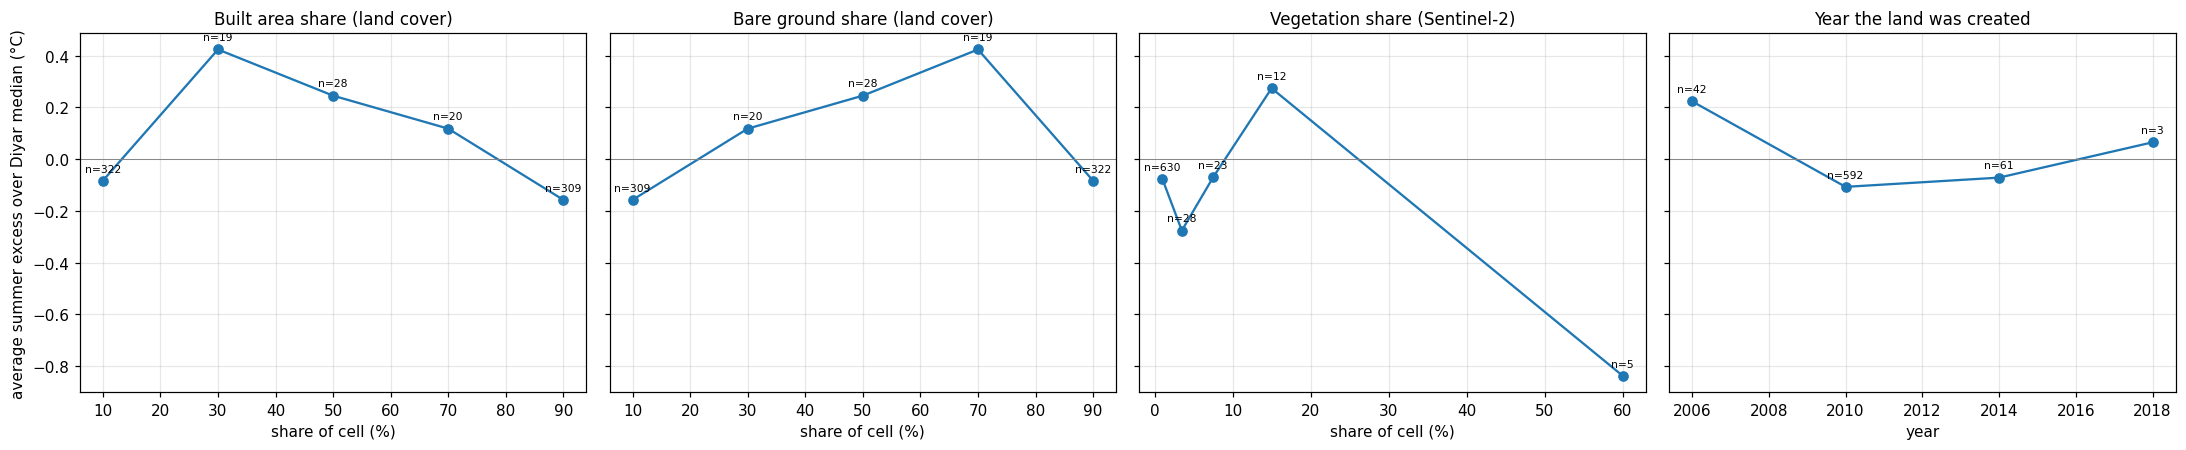

,spearman_rho,cells
surface,,
Built area share (land cover),-0.04,698
Bare ground share (land cover),0.04,698
Vegetation share (Sentinel-2),0.01,698
Year the land was created,-0.18,698


In [ ]:
drivers = {"Built area share (land cover)": (cells["built"], np.linspace(0, 1, 6), "share of cell (%)", 100),
           "Bare ground share (land cover)": (cells["bare"], np.linspace(0, 1, 6), "share of cell (%)", 100),
           "Vegetation share (Sentinel-2)": (cells["veg"], np.array([0, .02, .05, .1, .2, 1]), "share of cell (%)", 100),
           "Year the land was created": (cells["year"], np.arange(2000, 2030, 4), "year", 1)}
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2), sharey=True)
corr_rows = []
for ax, (name, (arr, bins, xlabel, scale)) in zip(axes, drivers.items()):
    ok = rank_c & np.isfinite(arr) & np.isfinite(A["excess"])
    cat = np.digitize(arr[ok], bins[1:-1])
    centres = (bins[:-1] + bins[1:]) / 2 * scale
    means = [np.mean(A["excess"][ok][cat == b]) if np.any(cat == b) else np.nan for b in range(len(bins) - 1)]
    ns = [int(np.sum(cat == b)) for b in range(len(bins) - 1)]
    ax.plot(centres, means, marker="o")
    for cx_, m_, n_ in zip(centres, means, ns):
        if np.isfinite(m_):
            ax.annotate(f"n={n_}", (cx_, m_), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=7)
    ax.axhline(0, color="grey", lw=0.6)
    ax.set_title(name); ax.set_xlabel(xlabel); ax.grid(alpha=0.3)
    rho = stats.spearmanr(arr[ok], A["excess"][ok]).statistic if ok.sum() > 10 else np.nan
    corr_rows.append({"surface": name, "spearman_rho": round(float(rho), 2), "cells": int(ok.sum())})
axes[0].set_ylabel("average summer excess over Diyar median (°C)")
plt.tight_layout(); save(fig, "q4_surface_vs_excess"); plt.show()
surface_correlations = pd.DataFrame(corr_rows).set_index("surface")
display(surface_correlations)

**What these graphs show:**
- **Built share (Spearman rho −0.04) and bare share (+0.04) are essentially unrelated to temperature.** Cells that are almost all built (90%) and cells that are almost all bare (10% built) both sit within 0.2 °C of the median. Mixed cells (30 to 70% built) run slightly warmer, +0.1 to +0.4 °C, but there are only 19 to 28 such cells, too few to rely on.
- **Vegetation (+0.01) cannot be tested here.** 630 of 698 cells have almost none. The 5 cells with substantial vegetation are 0.8 °C cooler, which points the expected way but is far too few cells to measure an effect.
- **Older land is slightly warmer (−0.18):** cells created around 2006 are about 0.2 °C above the median, cells created around 2010 about 0.1 °C below it. This is a weak relationship.

## 11. Q5: Hotspot zones and feedback for developers

### 11.1 From cells to zones

**What this does:** Joins touching hotspot cells (both hotspot classes) into zones, drops zones smaller than 2 cells (about 1.6 ha), and describes each zone: size, location, how much hotter than Diyar's median it typically is, how persistent it is, and its surface mix.

**The feedback rules:** Each zone gets a short, rule-based note chosen from what dominates its surface. The rules are transparent and come from measured composition, not from a prediction model:

| Condition | Main driver | Note for the developer |
|---|---|---|
| Bare ground ≥ 50% | Exposed reclaimed fill | Still unbuilt, so the layout is still open: plan shade and planted open space here before plots are built. |
| Built area ≥ 50% and vegetation < 10% | Dense hard surfaces | Built blocks with almost no planting: candidate measures are street trees, shade structures, and high-reflectance roofs and paving. |
| Otherwise | Mixed surfaces | Treat the unbuilt and paved parts first while they are still open. |

**Scope of the guidance:** The notes name candidate measures; they do not say how many degrees each would save. Vegetation is too rare in Diyar to measure its cooling effect here (Section 10.2); quantifying it requires sites where vegetation exists. The land cover map is from 2023, so a zone labelled "bare" may have been built on since; the natural-colour image in Section 8.3 can be used to check.

In [ ]:
zone_lab_c, n_z = ndimage.label(hot_c >= 1, structure=np.ones((3, 3)))
zone_rows = []
for zid in range(1, n_z + 1):
    m = zone_lab_c == zid
    if m.sum() < MIN_ZONE_CELLS:
        zone_lab_c[m] = 0
        continue
    built, bare, veg = (np.nanmean(cells[k][m]) for k in ("built", "bare", "veg"))
    if bare >= 0.5:
        driver, advice = "Exposed reclaimed fill", ("Still unbuilt, so the layout is still open: plan shade and "
                                                    "planted open space here before plots are built.")
    elif built >= 0.5 and veg < 0.1:
        driver, advice = "Dense hard surfaces", ("Built blocks with almost no planting: candidate measures are street "
                                                 "trees, shade structures, and high-reflectance roofs and paving.")
    else:
        driver, advice = "Mixed surfaces", "Treat the unbuilt and paved parts first while they are still open."
    r, c = ndimage.center_of_mass(m)
    lon_c, lat_c = to_ll.transform(T30.c + (c + 0.5) * CELL_M, T30.f - (r + 0.5) * CELL_M)
    zone_rows.append({"zone_id": zid, "area_ha": round(m.sum() * CELL_HA, 1),
                      "lat": round(lat_c, 5), "lon": round(lon_c, 5),
                      "excess_°C": round(float(np.nanmean(A["excess"][m])), 2),
                      "persistence": round(float(np.nanmean(A["freq"][m])), 2),
                      "persistent_share": round(float(np.mean(hot_c[m] == 2)), 2),
                      "stable_share": round(float(np.mean(stable_c[m])), 2),
                      "built_%": round(100 * built), "bare_%": round(100 * bare), "vegetation_%": round(100 * veg),
                      "year_created": int(np.nanmedian(cells["year"][m])) if np.isfinite(cells["year"][m]).any() else None,
                      "main_driver": driver, "guidance": advice})
zones = pd.DataFrame(zone_rows)
if len(zones):
    zones = zones.sort_values("excess_°C", ascending=False).reset_index(drop=True)
zone_lab = np.where(diyar_core, to_pixels(zone_lab_c), 0).astype("int32")
print(f"{len(zones)} hotspot zones of at least {MIN_ZONE_CELLS * CELL_HA:.1f} ha")
if len(zones):
    display(zones.drop(columns=["guidance"]))
    display(zones["main_driver"].value_counts().to_frame("zones"))

5 hotspot zones of at least 1.6 ha


,zone_id,area_ha,lat,lon,excess_°C,persistence,persistent_share,stable_share,built_%,bare_%,vegetation_%,year_created,main_driver
0,1,4.9,26.33283,50.63605,1.14,0.49,0.50,0.67,0,100,0,2012,Exposed reclaimed fill
1,5,79.4,26.30828,50.63599,1.09,0.41,0.37,0.50,68,32,2,2008,Dense hard surfaces
2,2,6.5,26.32381,50.64183,0.99,0.38,0.25,0.25,0,100,0,2009,Exposed reclaimed fill
3,3,4.9,26.32116,50.62767,0.82,0.23,0.00,0.00,0,100,0,2009,Exposed reclaimed fill
4,6,3.2,26.29953,50.64089,0.76,0.15,0.25,0.00,100,0,0,2008,Dense hard surfaces


,zones
main_driver,
Exposed reclaimed fill,3
Dense hard surfaces,2


**What the output shows:** Five hotspot zones meet the minimum size.
- **One large zone of 79 ha across the centre of the main island.**
  - About 1.1 °C above Diyar's median on a typical summer morning.
  - Hot in about 40% of scenes.
  - 68% built, so its note is "Dense hard surfaces".
  - Half of it is in the stable core.
- **Three small zones of 5 to 7 ha on the northern islands.**
  - 0.8 to 1.1 °C above the median.
  - 100% bare fill, so their note is "Exposed reclaimed fill".
  - These are the places where planting and shade can still be designed in before plots are built.
- **One small zone of 3 ha at the south of the main island.**
  - Built.
  - Not in the stable core.

### 11.2 Interactive map

**What this does:** Puts the hotspot zones and Diyar's outline on satellite imagery in an interactive map. Click a zone to see its numbers and guidance. This is a preview of what the web app will show a user.

In [ ]:
import folium

def vectorise(mask_or_labels, value_name):
    shapes = features.shapes(mask_or_labels.astype("int32"), mask=mask_or_labels > 0, transform=T30)
    gdf = gpd.GeoDataFrame([{value_name: int(v), "geometry": shape(g)} for g, v in shapes], crs=CRS)
    return gdf.dissolve(by=value_name).reset_index()

diyar_gdf = vectorise(diyar.astype(int), "diyar").to_crs("EPSG:4326")
zones_gdf = None
if len(zones):
    zones_gdf = vectorise(zone_lab, "zone_id").merge(zones, on="zone_id").to_crs("EPSG:4326")

m = folium.Map(location=[DIYAR_CENTRE[1], DIYAR_CENTRE[0]], zoom_start=14, tiles=None)
folium.TileLayer(tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
                 attr="Esri World Imagery", name="Satellite").add_to(m)
folium.GeoJson(diyar_gdf, name="Diyar reclaimed land",
               style_function=lambda f: {"color": "yellow", "weight": 1.5, "fillOpacity": 0}).add_to(m)
if zones_gdf is not None:
    folium.GeoJson(zones_gdf, name="Hotspot zones",
                   style_function=lambda f: {"color": "#d73027", "weight": 1, "fillColor": "#d73027",
                                             "fillOpacity": 0.45},
                   tooltip=folium.GeoJsonTooltip(fields=["zone_id", "area_ha", "excess_°C", "persistence",
                                                         "main_driver", "guidance"])).add_to(m)
folium.LayerControl().add_to(m)
m.save(str(OUT / "hotspot_map.html"))
m

**What this map shows:** The hotspot zones and Diyar's outline over satellite imagery. Clicking a zone opens its size, temperature excess, persistence, surface mix and guidance. The map is saved as `hotspot_map.html`, a standalone page that opens in any web browser with no software installed. In other words, it is already a working prototype of the Sidra user view.

**From this map to the Sidra web app:** Everything the map needs is already produced in web-standard formats, so the step to a full application is engineering, not new science.
- **Front end:** The map is built with Leaflet, the same open-source mapping library used by many production web maps. The hotspot zones are stored as GeoJSON, the standard format for web map layers, with every number and the guidance text attached to each zone. A web app can load this file directly and display the same clickable zones.
- **Back end:** This notebook becomes the analysis engine. A user draws or uploads a site boundary, the server runs the same pipeline on that area through the Planetary Computer catalogue, and returns the zones, the temperature layers (`hotspot_layers.tif`) and the summary metrics. No satellite images need to be stored in advance, because the data is streamed on demand for each site.
- **What the user sees:** One screen answering the three questions a developer has:
  - **Where is my site hottest?** The hotspot zones, with the stable core highlighted.
  - **Why?** The surface mix of each zone and its distance from water.
  - **What can I do about it?** The guidance note for each zone.
  - **Extra layers:** Toggles for summer surface temperature, the waterfront cooling band, and the before/after comparison showing what reclamation added.
- **Monitoring over time:** Because the analysis can be rerun every summer, the app can show each zone's history, so a developer or municipality can check whether planting, shading or new materials actually cooled it.
- **Fits existing platforms:** The same GeoJSON and GeoTIFF outputs can also be loaded into GIS software such as QGIS, or uploaded to geospatial platforms such as Space42 GIQ for delivery to clients.

**Why this matters for users:** Today, a developer who wants this information commissions a study after the district is built. With this pipeline behind a web app, any reclamation site can be assessed in one automated run from free satellite data, at the design stage, while there is still time to change the layout.

## 12. Save the results

**What this does:** Writes the results to `outputs/hotspots/` in the repository root, including when Jupyter starts in `notebooks/`. Set `SIDRA_ROOT` to use a different root. A standalone copy uses its starting directory:

| File | Contents |
|---|---|
| `hotspot_layers.tif` | One GeoTIFF with every 30 m layer as a named band (opens in QGIS or GIQ) |
| `hotspot_pixels.parquet` | One row per pixel with all layers as columns plus latitude and longitude |
| `hotspot_zones.geojson` | Zone outlines with their numbers and guidance (web app map layer) |
| `hotspot_map.html` | The interactive map from Section 11.2 |
| `hotspot_metrics.json` | Every setting, every satellite scene ID used, and the headline results |

Recording every scene ID means anyone can check exactly which images produced each number.

In [ ]:
layers = {
    "land_class": land_class, "is_diyar": diyar.astype("float32"), "year_created": conv_year,
    "lst_summer_median_c": lst_recent_median, "lst_above_sea_now_c": delta_recent_median,
    "lst_above_sea_before_c": delta_base_median, "in_hotspot_ranking": diyar_core.astype("float32"),
    "cell90_id": to_pixels(np.arange(NYc * NXc).reshape(NYc, NXc)),
    "excess_over_diyar_c": excess_c, "mean_z": on_core(A["z"]), "hot_persistence": hot_freq,
    "gi_star_z": gi_z, "hotspot_class": hot_class, "hotspot_stable": on_core(stable_c.astype(float)), "zone_id": np.where(zone_lab > 0, zone_lab, np.nan),
    "frac_built": frac["built"], "frac_bare": frac["bare"], "frac_vegetation_s2": frac_veg,
    "frac_vegetation_lulc": frac["vegetation_lulc"], "frac_water_s2": frac_water_s2, "ndvi": ndvi30,
    "dist_to_water_m": dist_to_water_m, "dist_to_reclaimed_m": dist_to_reclaimed_m, "n_clear_scenes": on_core(A["n_obs"]),
}
with rasterio.open(OUT / "hotspot_layers.tif", "w", driver="GTiff", height=NY, width=NX, count=len(layers),
                   dtype="float32", crs=CRS, transform=T30, nodata=np.nan, compress="deflate") as dst:
    for i, (name, arr) in enumerate(layers.items(), start=1):
        dst.write(np.asarray(arr, dtype="float32"), i)
        dst.set_band_description(i, name)

pixels = pd.DataFrame({k: np.asarray(v, dtype="float32").ravel() for k, v in layers.items()})
pixels.insert(0, "lat", LAT.ravel().astype("float32"))
pixels.insert(0, "lon", LON.ravel().astype("float32"))
pixels.insert(0, "col", np.tile(np.arange(NX), NY))
pixels.insert(0, "row", np.repeat(np.arange(NY), NX))
pixels = pixels[np.isfinite(pixels["land_class"])]
try:
    pixels.to_parquet(OUT / "hotspot_pixels.parquet", index=False)
    table_file = "hotspot_pixels.parquet"
except Exception:
    pixels.to_csv(OUT / "hotspot_pixels.csv.gz", index=False)
    table_file = "hotspot_pixels.csv.gz"

if zones_gdf is not None:
    zones_gdf.to_file(OUT / "hotspot_zones.geojson", driver="GeoJSON")

def scenes(items):
    return [{"id": it.id, "date": item_date(it).date().isoformat(), "satellite": it.properties.get("platform")}
            for it in items]

metrics = {
    "project": "Sidra: hotspot detection on reclaimed land", "site": "Diyar Al Muharraq, Bahrain",
    "study_bbox_lonlat": STUDY_BBOX, "crs": CRS, "pixel_m": PIXEL_M, "diyar_selection": selection_note,
    "settings": {k: v for k, v in globals().items() if k.isupper() and isinstance(v, (int, float, str, tuple, list))},
    "results": {
        "diyar_reclaimed_area_km2": round(float(diyar_area), 2),
        "diyar_reclamation_start_year_p5": reclamation_start,
        "recent_summer_scenes_used": int(lst_recent.sizes["time"]),
        "before_summer_scenes_used": int(lst_base.sizes["time"]) if HAVE_BASELINE else 0,
        "diyar_median_summer_lst_c": round(float(np.nanmedian(lst_recent_median[diyar])), 2),
        "before_after_table": before_after.reset_index().to_dict(orient="records"),
        "shore_buffer_m": shore_buffer, "coastal_cooling_0_30m_c": round(float(coastal_drop), 2),
        "coastal_profile": coast_profile.round(2).to_dict(orient="records"),
        "hotspot_cell_m": CELL_M, "ranked_cells": int(rank_c.sum()),
        "share_significant_uncorrected": round(float(uncorrected), 3),
        "share_significant_fdr": round(float(sig_c[rank_c].mean()), 3),
        "hotspot_area_ha": {HOT_NAMES[k]: round(float(np.sum(hot_c == k) * CELL_HA), 1) for k in HOT_NAMES},
        "hotspot_class_profile": profile.reset_index().to_dict(orient="records"),
        "vegetation_cover_ranked_pct": round(float(veg_cover), 2),
        "robustness": robustness.reset_index().to_dict(orient="records"),
        "surface_correlations": surface_correlations.reset_index().to_dict(orient="records"),
        "n_hotspot_zones": int(len(zones)),
        "stable_hotspot_area_ha": round(float(stable_c.sum() * CELL_HA), 1),
    },
    "data_sources": {
        "landsat_recent_summer_scenes": scenes(recent_items),
        "landsat_before_summer_scenes": scenes(base_items),
        "sentinel2_scenes": scenes(s2_items),
        "land_cover": {"collection": "io-lulc-annual-v02", "year": latest, "tiles": [it.id for it in lulc_items]},
        "landsat_history_scenes_per_year": history_log.to_dict(orient="records"),
    },
    "software": {"python": platform.python_version(), "odc-stac": odc.stac.__version__,
                 "xarray": xr.__version__, "numpy": np.__version__},
}
with open(OUT / "hotspot_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))

for p in sorted(OUT.glob("*")):
    if p.is_file():
        print(f"{p.name:28s} {p.stat().st_size / 1e6:6.2f} MB")
print(f"Pixel table rows: {len(pixels):,} ({table_file})")

hotspot_layers.tif             2.36 MB
hotspot_map.html               0.06 MB
hotspot_metrics.json           0.03 MB
hotspot_pixels.parquet         2.80 MB
hotspot_zones.geojson          0.01 MB
Pixel table rows: 126,315 (hotspot_pixels.parquet)


## 13. Conclusion: what this solves, and what we found

### The problem this addresses
Developers and planners building on reclaimed land had no site-specific evidence of how hot their land gets, where heat concentrates, or why. This notebook produces that evidence for Diyar Al Muharraq from free satellite data alone, with no ground sensors, and the same code can assess any other reclamation site by changing the study box and site location.

### The results, quantified

| What was measured | Result |
|---|---|
| Land reclaimed for Diyar | **11.4 km²**, created between 2007 and 2013 (published figure: 10 km²) |
| Summer surface temperature before reclamation | Same as the open sea (0.0 °C difference) |
| Summer surface temperature now | **14.0 °C above the open sea** (median 47.6 °C at the late-morning pass) |
| Warming caused by turning sea into land | **About 11.3 °C** (after removing 2.7 °C of background warming on older land) |
| Cooling from nearby water | Waterfront land is **7.5 °C cooler** than the interior; the effect reaches **180 m** inland |
| Share of Diyar inside that waterfront band | **About half** of its land |
| Hotspots in the inland half | **100 ha** (18% of ranked land), of which **34 ha persistent** |
| Most reliable hotspots (stable core) | **45 ha**, flagged under every alternative setting |
| How much hotter hotspots are | **+0.9 to +1.4 °C** above Diyar's median |
| Hotspot zones for developers | **5 zones**: one 79 ha built zone in the centre of the main island, three bare-fill zones on the northern islands, one small built zone |

### What it means
**1. Reclamation itself creates the heat.** Before it was built, the ground under Diyar behaved exactly like the surrounding sea. Today it is 14 °C hotter than the sea, and only 2.7 °C of that is matched by warming on older land. The rest, about 11 °C, comes from replacing water with dry land. The thermal cost of a reclamation project is largely set when the sea becomes land, before a single building goes up.

**2. Water is the strongest cooling factor in the data.** Land at the water is 7.5 °C cooler than the interior, and the effect reaches about 180 m inland. Because Diyar has many canals and inlets, about half of its land benefits. For a developer, this makes the amount of land within about 180 m of water (set by the island shapes and canals) a measurable design lever. Part of the drop in the first 100 m comes from the sensor footprint overlapping the sea, so the size of the effect close to the shore is an upper estimate.

**3. Inland hotspots are real but small compared with these two effects.** The hottest inland zones are about 1 to 1.5 °C above Diyar's median. That is consistent across years and settings, and enough to target with shade and material choices. But it is an order of magnitude smaller than the 11 °C created by reclamation and the 7.5 °C waterfront effect.

**4. "Built versus bare" does not explain where the hotspots are.** Across inland Diyar, the shares of built and bare land are almost unrelated to temperature (rho of −0.04 and +0.04). Both the hottest and the coolest clusters are mostly built. The differences most likely come from what a land cover map cannot see: specific materials (dark asphalt, large flat roofs, compacted fill), building density and shading. This is the gap that very-high-resolution imagery and Satellite 813 hyperspectral data can close, by identifying surface materials directly inside each zone.

**5. Diyar cannot show what greenery does.** Vegetation covers under 1% of inland Diyar, so this site contains no usable evidence, either way, about how much planting cools reclaimed land. Measuring that requires sites where vegetation exists.

### What a developer gets from this
- **A map of where their site runs hottest**, with a stable core they can trust and a softer margin around it.
- **A short note per zone** saying whether the heat sits on built blocks or open fill, and which measures fit.
- **Two numbers that put choices in proportion:** about 11 °C created by turning sea into land, and about 7.5 °C of cooling within 180 m of water.

## 14. Limitations

- **Time of day.** Landsat passes at about 10:30 to 11:00 local time. Afternoon peaks and night-time heat retention (where concrete and asphalt release stored heat) are not observed. Night-time behaviour may differ from the patterns shown here.
- **Surface, not air.** Surface temperature drives heat felt in the sun and heat released to the air, but it is not the air temperature people experience in the shade.
- **Effective resolution about 100 m.** Hotspots are found on 90 m cells and are block-scale. Individual buildings or roofs cannot be separated in temperature. Sub-meter imagery (Phase 2: MBZ-SAT, Planet) and Satellite 813 hyperspectral data would identify the specific materials inside each zone.
- **Land cover age.** The built-versus-bare map is from 2023; areas developed since then appear as bare.
- **Waterfront band not ranked.** Land within the measured cooling band (Section 9.1) is excluded from the hotspot ranking, so the hotspot map describes the inland half of Diyar only. The band itself is reported as a finding.
- **Significance is generous.** Even after correction, 35% of inland cells test as significant, because the temperature pattern is organised at a large scale. The stable core is the result to rely on.
- **Diyar's outline is derived, not official.** It is selected automatically from the reclamation map and checked against the published area. An official boundary file can replace it (`DIYAR_POLYGON_FILE`).
- **Tides and construction.** Intertidal flats and active reclamation can switch between water and land from scene to scene. Yearly medians and the "80% of later years" rule reduce but do not remove this.
- **Background change is approximate.** "Original land" mixes old neighbourhoods, the airport and roads, so its warming includes urban growth as well as climate and any small sensor difference. The 11.3 °C attributed to reclamation is therefore an estimate, not an exact figure.
- **Associations are not causes.** Section 10 shows which surfaces go with heat, not how much each surface type changes temperature when the others are held fixed.

## 15. Evaluation and scaling: from pilot to product

### How well the pilot performed

| Check | Result | What it shows |
|---|---|---|
| Reclaimed area vs published figure | 11.4 km² measured vs 10 km² published (+14%) | The method finds the right land without a hand-drawn boundary |
| Reclamation timeline | 5% by 2007, 95% by 2013, flat before 2006 | The "before" period is genuinely before reclamation |
| Sensor consistency (open sea, 1995-2006 vs 2021-2025) | +0.03 °C | Old and new satellites can be compared directly |
| Hotspot test vs reference software | Identical to 14 decimal places | The statistics are implemented correctly |
| Stability across years and settings | Gi\* rank correlation 0.90 to 0.99; 45 ha stable core | Where it is hot and cool is a consistent pattern, not noise |
| Not yet validated | No ground sensors; land cover map from 2023 | Ground measurements at a few hotspots are the next validation step |

### Why the method scales

- **Two inputs per site.** The analysis needs only a study box and a site location. Every dataset it uses is free, open and global, and is read through the same STAC catalogue, so a new site needs no new downloads, accounts or code.
- **History comes built in.** Landsat's thermal record reaches back to the 1980s, so any reclamation project built in the last four decades can be measured against its own "before" state, as Diyar was here.
- **Repeatable every summer.** Re-running each year turns a one-off assessment into monitoring: a developer can see whether a zone cools after planting or shading.
- **Web-ready outputs.** The hotspot zones are saved as GeoJSON with their numbers and guidance attached, which is the format a web map uses directly; the interactive map in Section 11.2 is a working preview of the user view.

### The size of the opportunity

- **Bahrain.** The Ministry of Works reports that land reclamation increased Bahrain's land area from 665 km² in 1981 to 741 km² in 2007, an 11% increase. This study box alone contains 25.3 km² of reclaimed land across Diyar, the Muharraq north coast and Amwaj Islands.
- **The Gulf.** A global satellite study of coastal cities (Sengupta et al., 2023) found that the United Arab Emirates is one of the three countries that added the most coastal land since 2000. Gulf summers make the thermal cost of that land a direct public-health and energy issue, and the same desert-coast conditions apply across the region.
- **Worldwide.** The same study measured over 2,530 km² of new land created since 2000 in 106 of the 135 largest coastal cities. Every one of those sites can be assessed with this method using the same free data.

### Path to a minimum viable product

1. **Site-agnostic pipeline (working now):** any study box and site location produces the full assessment and web-ready outputs.
2. **Web application:** a developer draws or uploads a site boundary and receives the hotspot map, the waterfront cooling profile and the zone guidance.
3. **Pre-construction mode:** add a predictive layer that estimates summer temperature for a proposed layout (share of land within 180 m of water, built and green share) before construction, trained on many sites across the Gulf.
4. **Richer data:** Satellite 813 hyperspectral imagery to identify the surface materials inside each hotspot, very-high-resolution imagery for building footprints, and ECOSTRESS thermal data to add other times of day than Landsat's late-morning pass.
5. **Ground validation:** temperature sensors at a few hotspot and cool-cluster sites with a partner developer or municipality, to calibrate the satellite results.

**Who would use it:** Reclamation developers and their environmental consultants (site assessment before and during design), municipalities and planning ministries (approval and monitoring), and governments setting heat-resilience standards for new coastal land.

### References
- Diyar Al Muharraq (2021). *Diyar Al Muharraq welcomes the Bahrain Economic Development Board on a Tour of the City*, press release, 13 April 2021. diyar.bh
- Ministry of Works, Bahrain, as cited in *Land reclamation in Bahrain*, Wikipedia.
- Sengupta, D., et al. (2023). Mapping 21st century global coastal land reclamation. *Earth's Future*. American Geophysical Union.
- U.S. Geological Survey. Landsat Collection 2 Level-2 Science Products.
- European Space Agency. Copernicus Sentinel-2 Level-2A.
- Impact Observatory and Esri. 10 m Annual Land Use Land Cover (v02).
- Rey, S. J., and Anselin, L. PySAL: A Python Library of Spatial Analytical Methods.

## 16. Download the results

**What this does:** Packs everything in `outputs/hotspots/` (the map layers, the pixel table, the hotspot zones, the interactive map, the figures, the metrics file and the cached yearly water maps) into one zip file, `hotspot_outputs.zip`, and downloads it to the computer.

**Why:** Files created in Colab are deleted when the session ends. Downloading them keeps the results, and the cached water maps let a later run skip the slowest step. The zip is saved as `outputs/hotspot_outputs.zip` in the repository root, or under `SIDRA_ROOT` if set. A standalone copy uses its starting directory.

In [ ]:
import shutil
archive = shutil.make_archive(str(OUT.parent / "hotspot_outputs"), "zip", root_dir=OUT.parent, base_dir=OUT.name)
print(f"Created {archive} ({Path(archive).stat().st_size / 1e6:.1f} MB)")
try:
    from google.colab import files
    files.download(archive)
except ImportError:
    print("Not running in Colab: the zip file is saved at", archive)